<a href="https://colab.research.google.com/github/hemanthkumarakunurids26sp-hue/Store_Sales/blob/main/Master_Rossmann_Project_Expanded.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
train = pd.read_csv(r"train.csv")
store = pd.read_csv(r"store.csv")
train.info()
store.info()

/tmp/ipykernel_2100/2463398652.py:1: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv(r"train.csv")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype 
---  ------         --------------    ----- 
 0   Store          1017209 non-null  int64 
 1   DayOfWeek      1017209 non-null  int64 
 2   Date           1017209 non-null  object
 3   Sales          1017209 non-null  int64 
 4   Customers      1017209 non-null  int64 
 5   Open           1017209 non-null  int64 
 6   Promo          1017209 non-null  int64 
 7   StateHoliday   1017209 non-null  object
 8   SchoolHoliday  1017209 non-null  int64 
dtypes: int64(7), object(2)
memory usage: 69.8+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1115 entries, 0 to 1114
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Store                      1115 non-null   int64  
 1   StoreType                  1115 non-null   object 
 2   Assort

In [ ]:
df = pd.merge(train, store, on="Store", how="left")
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype  
---  ------                     --------------    -----  
 0   Store                      1017209 non-null  int64  
 1   DayOfWeek                  1017209 non-null  int64  
 2   Date                       1017209 non-null  object 
 3   Sales                      1017209 non-null  int64  
 4   Customers                  1017209 non-null  int64  
 5   Open                       1017209 non-null  int64  
 6   Promo                      1017209 non-null  int64  
 7   StateHoliday               1017209 non-null  object 
 8   SchoolHoliday              1017209 non-null  int64  
 9   StoreType                  1017209 non-null  object 
 10  Assortment                 1017209 non-null  object 
 11  CompetitionDistance        1014567 non-null  float64
 12  CompetitionOpenSinceMonth  693861 non-null   float64
 13  CompetitionO

## Claim - The promo is impacting the sales, wherever we have promo, the avg sales in inceases
# hypothesis
H0= No change in avg Sales despite promo

H1= Change in avg sales due to promo impact




In [ ]:
df.groupby("Promo")["Sales"].mean()


,Sales
Promo,
0,4406.050805
1,7991.152046


In [ ]:
df.groupby("Promo")["Sales"].std()



,Sales
Promo,
0,3442.450020
1,3419.025495


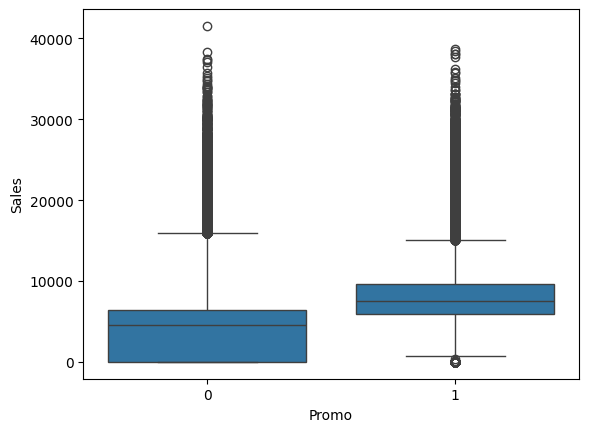

In [ ]:
sns.boxplot(x="Promo",y="Sales",data=df)
plt.show()

In [ ]:
df_cleaned = df[['Promo', 'Sales']].dropna()
X = df_cleaned["Promo"]
y = df_cleaned["Sales"]

model = sm.OLS(y,sm.add_constant(X))
results = model.fit()

print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.205
Model:                            OLS   Adj. R-squared:                  0.205
Method:                 Least Squares   F-statistic:                 2.617e+05
Date:                Fri, 04 Sep 2026   Prob (F-statistic):               0.00
Time:                        05:09:57   Log-Likelihood:            -9.7248e+06
No. Observations:             1017209   AIC:                         1.945e+07
Df Residuals:                 1017207   BIC:                         1.945e+07
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       4406.0508      4.329   1017.837      0.0

Pvalue is 0 which is less tha our default 0.05 so we reject our null hypothesis, which suggests that the presence of Promo has significant impact on the sales.


In [ ]:
#Get unique values of each column - Open, Promo, StateHoliday, SchoolHoliday, StoreType, Assortment, Promo2 and PromoInterval
df.nunique()[["Promo", "StateHoliday", "SchoolHoliday", "StoreType", "Assortment", "Promo2", "PromoInterval"]]


,0
Promo,2
StateHoliday,5
SchoolHoliday,2
StoreType,4
Assortment,3
Promo2,2
PromoInterval,3


# Hypothesis testing with the Sales and School Holiday (0,1)

## Claim: During the holidays the avg sales increases

### Hypothesis:
H1: The Avg sales changes when the schools are giving holidays

H0: There is no change in the avg sales when the schools are giving holidays

In [ ]:
df.groupby("SchoolHoliday")['Sales'].mean()

,Sales
SchoolHoliday,
0,5620.979034
1,6476.522207


In [ ]:
df.groupby('SchoolHoliday')['Sales'].std()

,Sales
SchoolHoliday,
0,3862.873159
1,3709.677337


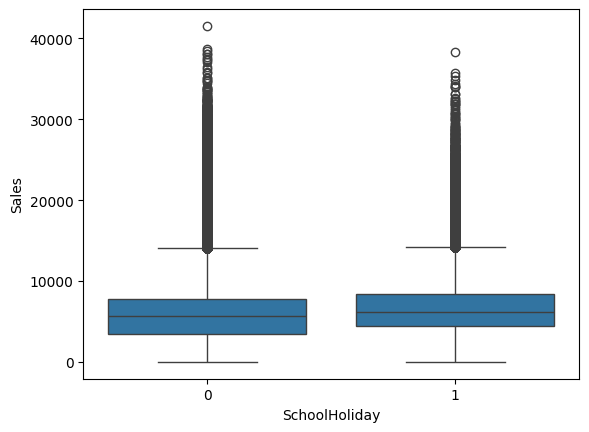

In [ ]:
sns.boxplot(x='SchoolHoliday',y='Sales',data=df)
plt.show()

In [ ]:
df_cleaned = df[['SchoolHoliday', 'Sales']].dropna()
y = df_cleaned['SchoolHoliday']
x = df_cleaned['Sales']

model=sm.OLS(y,sm.add_constant(x))
result=model.fit()

print(result.summary())

                            OLS Regression Results                            
Dep. Variable:          SchoolHoliday   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                     7425.
Date:                Fri, 04 Sep 2026   Prob (F-statistic):               0.00
Time:                        05:10:02   Log-Likelihood:            -4.6357e+05
No. Observations:             1017209   AIC:                         9.271e+05
Df Residuals:                 1017207   BIC:                         9.272e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1297      0.001    190.206      0.0

# Hypothesis testing with the Sales and Store Types (a,b,c,d)

## Claim: Each store typs has a different avg of sales.

### Hypothesis:
H1: The Avg sales is different for atleast one store

H0: There is no change in the avg sales for all the store types

In [ ]:
df.groupby('StoreType')['Sales'].mean()

,Sales
StoreType,
a,5738.179710
b,10058.837334
c,5723.629246
d,5641.819243


In [ ]:
df.groupby('StoreType')['Sales'].std()

,Sales
StoreType,
a,3964.028134
b,5280.525506
c,3721.700886
d,3473.393781


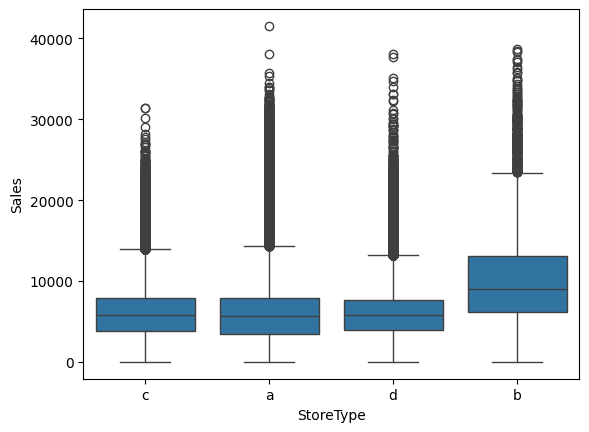

In [ ]:
sns.boxplot(x='StoreType',y='Sales',data=df)
plt.show()

In [ ]:
y = df['Sales']
X = pd.get_dummies(df['StoreType'], drop_first=True, dtype=int)
print(x.head())
anova_model = sm.OLS(y, sm.add_constant(X))
result = anova_model.fit()

print(result.summary())

0     5263
1     6064
2     8314
3    13995
4     4822
Name: Sales, dtype: int64
                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.020
Model:                            OLS   Adj. R-squared:                  0.020
Method:                 Least Squares   F-statistic:                     6817.
Date:                Fri, 04 Sep 2026   Prob (F-statistic):               0.00
Time:                        05:10:10   Log-Likelihood:            -9.8311e+06
No. Observations:             1017209   AIC:                         1.966e+07
Df Residuals:                 1017205   BIC:                         1.966e+07
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------

Checking significance between the store types b and d

In [ ]:
from scipy import stats

sales_store_b = df[df['StoreType'] == 'b']['Sales']
sales_store_d = df[df['StoreType'] == 'd']['Sales']

t_stat, p_value = stats.ttest_ind(sales_store_b, sales_store_d, equal_var=False) # Assuming unequal variances

print(f"T-statistic: {t_stat:.2f}")
print(f"P-value: {p_value:.3e}")

T-statistic: 104.11
P-value: 0.000e+00


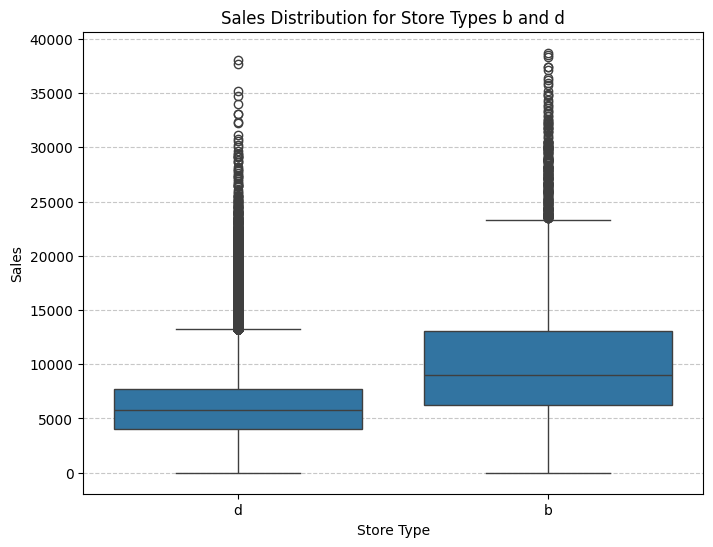

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='StoreType', y='Sales', data=df[df['StoreType'].isin(['b', 'd'])])
plt.title('Sales Distribution for Store Types b and d')
plt.xlabel('Store Type')
plt.ylabel('Sales')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Interpretation of the t-test results:

*   **T-statistic:** This value measures the difference between the means of the two groups (StoreType 'b' and 'd') relative to the variation within the groups.
*   **P-value:** This is the probability of observing such a difference (or a more extreme one) if the null hypothesis were true. The null hypothesis (H0) states that there is no significant difference in sales between StoreType 'b' and StoreType 'd'. The alternative hypothesis (H1) states that there is a significant difference.

If the p-value is less than a chosen significance level (e.g., 0.05), we reject the null hypothesis and conclude that there is a statistically significant difference in sales between the two store types.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype  
---  ------                     --------------    -----  
 0   Store                      1017209 non-null  int64  
 1   DayOfWeek                  1017209 non-null  int64  
 2   Date                       1017209 non-null  object 
 3   Sales                      1017209 non-null  int64  
 4   Customers                  1017209 non-null  int64  
 5   Open                       1017209 non-null  int64  
 6   Promo                      1017209 non-null  int64  
 7   StateHoliday               1017209 non-null  object 
 8   SchoolHoliday              1017209 non-null  int64  
 9   StoreType                  1017209 non-null  object 
 10  Assortment                 1017209 non-null  object 
 11  CompetitionDistance        1014567 non-null  float64
 12  CompetitionOpenSinceMonth  693861 non-null   float64
 13  CompetitionO

In [ ]:
colums = ["Open", "Promo", "StateHoliday", "SchoolHoliday", "StoreType", "Assortment", "Promo2", "PromoInterval"]
for col in colums:
    print(f"Unique values in column '{col}': {df[col].unique()}")

Unique values in column 'Open': [1 0]
Unique values in column 'Promo': [1 0]
Unique values in column 'StateHoliday': ['0' 'a' 'b' 'c' 0]
Unique values in column 'SchoolHoliday': [1 0]
Unique values in column 'StoreType': ['c' 'a' 'd' 'b']
Unique values in column 'Assortment': ['a' 'c' 'b']
Unique values in column 'Promo2': [0 1]
Unique values in column 'PromoInterval': [nan 'Jan,Apr,Jul,Oct' 'Feb,May,Aug,Nov' 'Mar,Jun,Sept,Dec']


## Claim 4:
Each Assortment type has the different impact on the average Customers.

### Hypothesis:
H0 : Avg Customers is same across all the Assortments
H1 : Avg Customers is different in atleast one of the Assortments



In [ ]:
df.groupby("Assortment")['Customers'].mean()

,Customers
Assortment,
a,619.164636
b,2046.361828
c,624.222733


In [ ]:
df.groupby("Assortment")['Customers'].std()

,Customers
Assortment,
a,440.713326
b,867.681445
c,441.865660


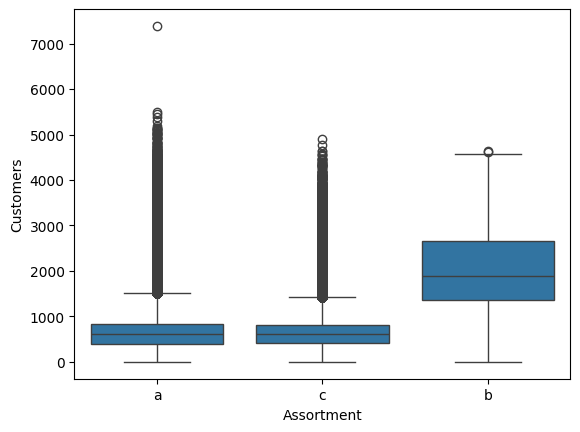

In [ ]:
sns.boxplot(x='Assortment',y='Customers',data=df)
plt.show()


We can see a clar spike of avg customers in Assortment B compared to the others

Lets test our hypothesis now

In [ ]:
y=df['Customers']
X = pd.get_dummies(df['Assortment'], drop_first=True, dtype=int)
model=sm.OLS(y,sm.add_constant(X))
result=model.fit()

print(result.summary())

                            OLS Regression Results                            
Dep. Variable:              Customers   R-squared:                       0.076
Model:                            OLS   Adj. R-squared:                  0.076
Method:                 Least Squares   F-statistic:                 4.192e+04
Date:                Fri, 04 Sep 2026   Prob (F-statistic):               0.00
Time:                        05:10:16   Log-Likelihood:            -7.6495e+06
No. Observations:             1017209   AIC:                         1.530e+07
Df Residuals:                 1017206   BIC:                         1.530e+07
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        619.1646      0.609   1016.880      0.0

The p value is 0.00 for B and C on comparing with A, this means that the avg customers number is different across each assortment, depite A and C having similar mean and standard deviations

## Claim 4:
Each Assortment type has the different impact on the average Sales.

### Hypothesis:
H0 : Avg Sales is same across all the Assortments
H1 : Avg Sales is different in atleast one of the Assortments


In [ ]:
df.groupby("Assortment")['Sales'].mean()

,Sales
Assortment,
a,5481.026096
b,8553.931999
c,6058.676567


In [ ]:
df.groupby("Assortment")['Sales'].std()

,Sales
Assortment,
a,3682.766186
b,3882.418206
c,3992.255662


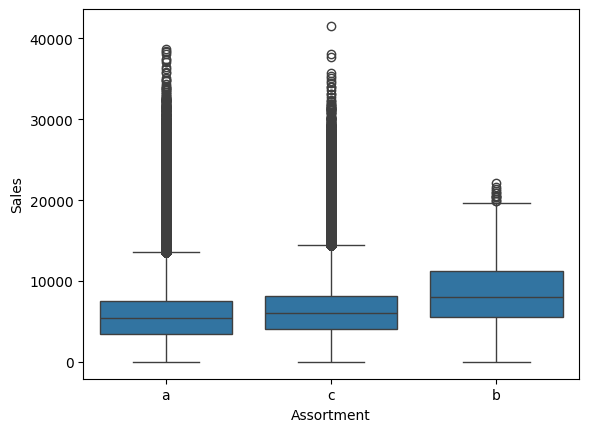

In [ ]:
sns.boxplot(x='Assortment',y='Sales',data=df)
plt.show()

In [ ]:
X=pd.get_dummies(df['Assortment'],drop_first=True,dtype=int)
y=df['Sales']
model=sm.OLS(y,sm.add_constant(X))
result=model.fit()

print(result.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.010
Model:                            OLS   Adj. R-squared:                  0.010
Method:                 Least Squares   F-statistic:                     5057.
Date:                Fri, 04 Sep 2026   Prob (F-statistic):               0.00
Time:                        05:10:20   Log-Likelihood:            -9.8362e+06
No. Observations:             1017209   AIC:                         1.967e+07
Df Residuals:                 1017206   BIC:                         1.967e+07
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       5481.0261      5.226   1048.877      0.0

In [ ]:
store_types_with_assortment_b = df[df['Assortment'] == 'b']['StoreType'].unique()
print(store_types_with_assortment_b)

['b']


In [ ]:
#convert all the values in StateHoliday column to string
df["StateHoliday"] = df["StateHoliday"].astype(str)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype  
---  ------                     --------------    -----  
 0   Store                      1017209 non-null  int64  
 1   DayOfWeek                  1017209 non-null  int64  
 2   Date                       1017209 non-null  object 
 3   Sales                      1017209 non-null  int64  
 4   Customers                  1017209 non-null  int64  
 5   Open                       1017209 non-null  int64  
 6   Promo                      1017209 non-null  int64  
 7   StateHoliday               1017209 non-null  object 
 8   SchoolHoliday              1017209 non-null  int64  
 9   StoreType                  1017209 non-null  object 
 10  Assortment                 1017209 non-null  object 
 11  CompetitionDistance        1014567 non-null  float64
 12  CompetitionOpenSinceMonth  693861 non-null   float64
 13  CompetitionO

In [ ]:
df.groupby("StateHoliday")['Sales'].mean()

,Sales
StateHoliday,
0,5947.483893
a,290.735686
b,214.311510
c,168.733171


In [ ]:
df.groupby("StateHoliday")['Sales'].std()

,Sales
StateHoliday,
0,3767.890619
a,1870.281698
b,1816.918138
c,1492.274865


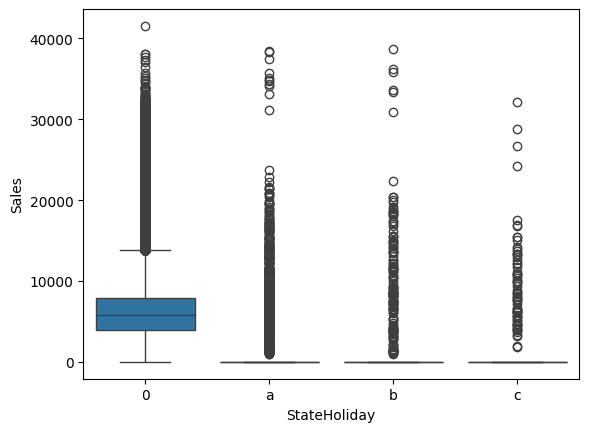

In [ ]:
sns.boxplot(x='StateHoliday',y='Sales',data=df)
plt.show()

In [ ]:
X=pd.get_dummies(df['StateHoliday'],drop_first=True,dtype=int)
y=df['Sales']
model=sm.OLS(y,sm.add_constant(X))
results = model.fit()

print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.065
Model:                            OLS   Adj. R-squared:                  0.065
Method:                 Least Squares   F-statistic:                 2.343e+04
Date:                Fri, 04 Sep 2026   Prob (F-statistic):               0.00
Time:                        05:10:24   Log-Likelihood:            -9.8073e+06
No. Observations:             1017209   AIC:                         1.961e+07
Df Residuals:                 1017205   BIC:                         1.961e+07
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       5947.4839      3.749   1586.215      0.0

### ANOVA test

Claim: Sales are dependent on the Promo Intervals

H0 : Avg sales is same across all the Promo Intervals

H1: Avg sales differs in atleas one of the Promo Intervals

In [ ]:
df['PromoInterval']=df['PromoInterval'].fillna('No Promo')
df.groupby('PromoInterval')['Sales'].mean()

,Sales
PromoInterval,
"Feb,May,Aug,Nov",5311.048585
"Jan,Apr,Jul,Oct",5562.364063
"Mar,Jun,Sept,Dec",5143.829243
No Promo,6124.710161


In [ ]:
df.groupby('PromoInterval')['Sales'].std()

,Sales
PromoInterval,
"Feb,May,Aug,Nov",3381.166345
"Jan,Apr,Jul,Oct",3609.884075
"Mar,Jun,Sept,Dec",3314.203545
No Promo,4136.143923


In [ ]:
X=pd.get_dummies(df['PromoInterval'],drop_first=True,dtype=int)
y=df['Sales']
model=sm.OLS(y,sm.add_constant(X))
results = model.fit()

print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.009
Model:                            OLS   Adj. R-squared:                  0.009
Method:                 Least Squares   F-statistic:                     3172.
Date:                Fri, 04 Sep 2026   Prob (F-statistic):               0.00
Time:                        05:10:24   Log-Likelihood:            -9.8365e+06
No. Observations:             1017209   AIC:                         1.967e+07
Df Residuals:                 1017205   BIC:                         1.967e+07
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const             5311.0486     11.127  

P value = 0, f statistic = 3172,

Reject H0 and the Promo Interval column is highly significant

In [ ]:
df.columns

Index(['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo',
       'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment',
       'CompetitionDistance', 'CompetitionOpenSinceMonth',
       'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek',
       'Promo2SinceYear', 'PromoInterval'],
      dtype='object')

# ANOVA Test for the day of the week

### Claim : The avg sales differs as per what day of the week it is

H0: Avg sales is sames across all the days of the week

H1: Avg sales is diff in atleast one of them



In [ ]:
df.groupby('DayOfWeek')['Sales'].mean()

,Sales
DayOfWeek,
1,7809.044510
2,7005.244467
3,6555.884138
4,6247.575913
5,6723.274305
6,5847.562599
7,204.183189


In [ ]:
df.groupby('DayOfWeek')['Sales'].std()

,Sales
DayOfWeek,
1,4016.526273
2,3142.039607
3,2944.377501
4,3209.806360
5,3101.006008
6,2873.985615
7,1613.243517


In [ ]:
X=pd.get_dummies(df['DayOfWeek'],drop_first=True,dtype=int)
y=df['Sales']
model=sm.OLS(y,sm.add_constant(X))
results = model.fit()

print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.369
Model:                            OLS   Adj. R-squared:                  0.369
Method:                 Least Squares   F-statistic:                 9.916e+04
Date:                Fri, 04 Sep 2026   Prob (F-statistic):               0.00
Time:                        05:10:25   Log-Likelihood:            -9.6070e+06
No. Observations:             1017209   AIC:                         1.921e+07
Df Residuals:                 1017202   BIC:                         1.921e+07
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       7809.0445      8.038    971.460      0.0

P value =0 --> Reject H0

all the days of the week are significant, and we cannot ignore this information.

In [ ]:
#building a chi-squared test for categorical varaibles like StateHoliday, SchoolHoliday, StoreType, Assortment, Promo2 and PromoInterval
# let us consider store type and assortment for the chi-squared test now
df[['StoreType', 'Assortment']].head()

,StoreType,Assortment
0,c,a
1,a,a
2,a,a
3,c,c
4,a,a


In [ ]:
df[['StoreType', 'Assortment']].value_counts()

StoreType  Assortment
a          a             346389
           c             205238
d          c             199328
           a             113584
c          a              70878
           c              65962
b          b               8294
           a               6594
           c                942
Name: count, dtype: int64

In [ ]:
from statsmodels.stats.contingency_tables import Table
chi_table=pd.crosstab(df['StoreType'], df['Assortment'], margins=True, margins_name="Total")
chi_table

Assortment,a,b,c,Total
StoreType,,,,
a,346389,0,205238,551627
b,6594,8294,942,15830
c,70878,0,65962,136840
d,113584,0,199328,312912
Total,537445,8294,471470,1017209


In [ ]:
table = Table(chi_table)
chi_test = table.test_nominal_association()
print("Chi-Squared Statistic:", chi_test.statistic)
print("p-Value:", chi_test.pvalue)
print("Degrees of Freedom:", chi_test.df)
print("Expected Frequencies:\n", table.fittedvalues)

Chi-Squared Statistic: 587517.6833082866
p-Value: 0.0
Degrees of Freedom: 12
Expected Frequencies:
 Assortment              a            b              c         Total
StoreType                                                          
a           291453.573534  4498.198940  255675.680887  5.516270e+05
b             8363.818265   129.084430    7337.103141  1.582999e+04
c            72299.872542  1115.852539   63424.575366  1.368402e+05
d           165327.933791  2551.617149  145032.814417  3.129121e+05
Total       537444.801868  8294.746942  471469.826190  1.017209e+06


In [ ]:
from statsmodels.stats.contingency_tables import Table

def perform_chi_squared_test(dataframe, col1, col2):
    """
    Performs a Chi-squared test of independence between two categorical columns.

    Args:
        dataframe (pd.DataFrame): The input DataFrame.
        col1 (str): Name of the first categorical column.
        col2 (str): Name of the second categorical column.
    """
    # Ensure columns are of string type for consistent handling of unique values
    df_copy = dataframe[[col1, col2]].copy()
    df_copy[col1] = df_copy[col1].astype(str)
    df_copy[col2] = df_copy[col2].astype(str)

    # Create contingency table
    contingency_table = pd.crosstab(df_copy[col1], df_copy[col2])

    print(f"--- Contingency Table for {col1} vs {col2} ---")
    display(contingency_table)
    print("\n" + "="*40 + "\n")

    # Initialize statsmodels Table object
    table = Table(contingency_table)

    # Run Chi-Square test
    test_results = table.test_nominal_association()

    chi2_stat = test_results.statistic
    p_value = test_results.pvalue
    dof = test_results.df

    print("--- Chi-Square Test Results ---")
    print(f"Chi-Square Statistic: {chi2_stat:.4f}")
    print(f"p-value:             {p_value:.4f}")
    print(f"Degrees of Freedom:   {dof}")

    alpha = 0.05
    if p_value < alpha:
        print(f"\nConclusion: Reject the null hypothesis (alpha={alpha}). There is a statistically significant dependency between {col1} and {col2}.")
    else:
        print(f"\nConclusion: Fail to reject the null hypothesis (alpha={alpha}). {col1} and {col2} are independent.")

# Example usage:
# Replace 'StoreType' and 'StateHoliday' with any two categorical columns you want to test
perform_chi_squared_test(df, 'StoreType', 'StateHoliday')


--- Contingency Table for StoreType vs StateHoliday ---


StateHoliday,0,a,b,c
StoreType,,,,
a,534942,10833,3612,2240
b,15372,290,102,66
c,132758,2630,888,564
d,303087,6507,2088,1230




--- Chi-Square Test Results ---
Chi-Square Statistic: 21.9966
p-value:             0.0089
Degrees of Freedom:   9

Conclusion: Reject the null hypothesis (alpha=0.05). There is a statistically significant dependency between StoreType and StateHoliday.


In [ ]:
perform_chi_squared_test(df, 'Assortment', 'Promo')

--- Contingency Table for Assortment vs Promo ---


Promo,0,1
Assortment,,
a,332475,204970
b,5128,3166
c,291526,179944




--- Chi-Square Test Results ---
Chi-Square Statistic: 0.0894
p-value:             0.9563
Degrees of Freedom:   2

Conclusion: Fail to reject the null hypothesis (alpha=0.05). Assortment and Promo are independent.


In [ ]:
perform_chi_squared_test(df, 'Promo', 'Assortment')

--- Contingency Table for Promo vs Assortment ---


Assortment,a,b,c
Promo,,,
0,332475,5128,291526
1,204970,3166,179944




--- Chi-Square Test Results ---
Chi-Square Statistic: 0.0894
p-value:             0.9563
Degrees of Freedom:   2

Conclusion: Fail to reject the null hypothesis (alpha=0.05). Promo and Assortment are independent.


In [ ]:
df['PromoInterval'].nunique()

4

In [ ]:
df['PromoInterval'] = df['PromoInterval'].fillna('No Promo')

In [ ]:
perform_chi_squared_test(df, 'PromoInterval', 'StoreType')

--- Contingency Table for PromoInterval vs StoreType ---


StoreType,a,b,c,d
PromoInterval,,,,
"Feb,May,Aug,Nov",60332,942,14704,42618
"Jan,Apr,Jul,Oct",154590,2826,33956,101750
"Mar,Jun,Sept,Dec",42964,758,19598,34140
No Promo,293741,11304,68582,134404




--- Chi-Square Test Results ---
Chi-Square Statistic: 16594.1464
p-value:             0.0000
Degrees of Freedom:   9

Conclusion: Reject the null hypothesis (alpha=0.05). There is a statistically significant dependency between PromoInterval and StoreType.


In [ ]:
perform_chi_squared_test(df, 'SchoolHoliday', 'StateHoliday')

--- Contingency Table for SchoolHoliday vs StateHoliday ---


StateHoliday,0,a,b,c
SchoolHoliday,,,,
0,819949,15055,484,0
1,166210,5205,6206,4100




--- Chi-Square Test Results ---
Chi-Square Statistic: 45957.2397
p-value:             0.0000
Degrees of Freedom:   3

Conclusion: Reject the null hypothesis (alpha=0.05). There is a statistically significant dependency between SchoolHoliday and StateHoliday.


In [ ]:
perform_chi_squared_test(df, 'StoreType', 'Promo')

--- Contingency Table for StoreType vs Promo ---


Promo,0,1
StoreType,,
a,341123,210504
b,9784,6046
c,84596,52244
d,193626,119286




--- Chi-Square Test Results ---
Chi-Square Statistic: 0.1957
p-value:             0.9783
Degrees of Freedom:   3

Conclusion: Fail to reject the null hypothesis (alpha=0.05). StoreType and Promo are independent.


In [ ]:
perform_chi_squared_test(df, 'StoreType', 'PromoInterval')

--- Contingency Table for StoreType vs PromoInterval ---


PromoInterval,"Feb,May,Aug,Nov","Jan,Apr,Jul,Oct","Mar,Jun,Sept,Dec",No Promo
StoreType,,,,
a,60332,154590,42964,293741
b,942,2826,758,11304
c,14704,33956,19598,68582
d,42618,101750,34140,134404




--- Chi-Square Test Results ---
Chi-Square Statistic: 16594.1464
p-value:             0.0000
Degrees of Freedom:   9

Conclusion: Reject the null hypothesis (alpha=0.05). There is a statistically significant dependency between StoreType and PromoInterval.


In [ ]:
import itertools
from statsmodels.stats.contingency_tables import Table

# List of categorical columns identified from the dataframe's info and unique values
# 'Open' and 'Promo2' are binary and have been implicitly handled elsewhere or are less critical
# for this broad pairwise analysis. Focusing on the main categorical ones.
categorical_columns = ['StateHoliday', 'StoreType', 'Assortment', 'PromoInterval', 'SchoolHoliday', 'Promo','Promo2']

# Ensure PromoInterval has no NaNs as done previously in the notebook
df['PromoInterval'] = df['PromoInterval'].fillna('No Promo')

# Initialize an empty list to store test results
chi_squared_results = []

# Iterate over all unique pairs of categorical columns
for col1, col2 in itertools.combinations(categorical_columns, 2):
    # Create contingency table
    contingency_table = pd.crosstab(df[col1].astype(str), df[col2].astype(str))

    # Check if the contingency table is valid for chi-squared test (e.g., not all zeros)
    if contingency_table.sum().sum() == 0:
        print(f"Skipping Chi-squared test for {col1} vs {col2} due to empty contingency table.")
        continue

    # Initialize statsmodels Table object
    table = Table(contingency_table)

    # Run Chi-Square test for nominal association
    test_results = table.test_nominal_association()

    chi2_stat = test_results.statistic
    p_value = test_results.pvalue
    dof = test_results.df

    # Store results in a dictionary
    result_entry = {
        'Variable 1': col1,
        'Variable 2': col2,
        'Chi-Square Statistic': chi2_stat,
        'P-value': p_value,
        'Degrees of Freedom': dof,
        'Significant (alpha=0.05)': 'Yes' if p_value < 0.05 else 'No'
    }
    chi_squared_results.append(result_entry)

# Convert the list of dictionaries to a DataFrame
results_df = pd.DataFrame(chi_squared_results)

print("Chi-Squared Test Results for all Categorical Variable Pairs:")
print(results_df)

Chi-Squared Test Results for all Categorical Variable Pairs:
       Variable 1     Variable 2  Chi-Square Statistic       P-value  \
0    StateHoliday      StoreType          2.199665e+01  8.889604e-03   
1    StateHoliday     Assortment          1.310405e+01  4.141303e-02   
2    StateHoliday  PromoInterval          1.585706e+02  0.000000e+00   
3    StateHoliday  SchoolHoliday          4.595724e+04  0.000000e+00   
4    StateHoliday          Promo          2.946778e+03  0.000000e+00   
5    StateHoliday         Promo2          1.338685e+02  0.000000e+00   
6       StoreType     Assortment          5.874709e+05  0.000000e+00   
7       StoreType  PromoInterval          1.659415e+04  0.000000e+00   
8       StoreType  SchoolHoliday          6.258535e+00  9.968747e-02   
9       StoreType          Promo          1.957320e-01  9.782753e-01   
10      StoreType         Promo2          1.144851e+04  0.000000e+00   
11     Assortment  PromoInterval          7.777986e+03  0.000000e+00   
12 

In [ ]:
print(results_df[results_df['Significant (alpha=0.05)']=='No'])

       Variable 1     Variable 2  Chi-Square Statistic   P-value  \
8       StoreType  SchoolHoliday              6.258535  0.099687   
9       StoreType          Promo              0.195732  0.978275   
13     Assortment          Promo              0.089372  0.956298   
16  PromoInterval          Promo              1.466960  0.689917   
20          Promo         Promo2              0.982431  0.321599   

    Degrees of Freedom Significant (alpha=0.05)  
8                    3                       No  
9                    3                       No  
13                   2                       No  
16                   3                       No  
20                   1                       No  


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype  
---  ------                     --------------    -----  
 0   Store                      1017209 non-null  int64  
 1   DayOfWeek                  1017209 non-null  int64  
 2   Date                       1017209 non-null  object 
 3   Sales                      1017209 non-null  int64  
 4   Customers                  1017209 non-null  int64  
 5   Open                       1017209 non-null  int64  
 6   Promo                      1017209 non-null  int64  
 7   StateHoliday               1017209 non-null  object 
 8   SchoolHoliday              1017209 non-null  int64  
 9   StoreType                  1017209 non-null  object 
 10  Assortment                 1017209 non-null  object 
 11  CompetitionDistance        1014567 non-null  float64
 12  CompetitionOpenSinceMonth  693861 non-null   float64
 13  CompetitionO

In [ ]:
df.columns

Index(['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo',
       'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment',
       'CompetitionDistance', 'CompetitionOpenSinceMonth',
       'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek',
       'Promo2SinceYear', 'PromoInterval'],
      dtype='object')

In [ ]:
#the avg sales of assortyment'b' is more with the presence of a promo



In [ ]:
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm

# Ensure 'Promo' and 'Assortment' are treated as categorical variables
# Although `smf.ols` with `C()` will handle this, explicit conversion is good practice.
# We are making a copy to avoid SettingWithCopyWarning if further modifications were made.
df_anova = df.copy()
df_anova['Promo'] = df_anova['Promo'].astype('category')
df_anova['Assortment'] = df_anova['Assortment'].astype('category')

# Define the ANOVA model formula
# Sales is the dependent variable
# C(Assortment) and C(Promo) are categorical independent variables
# C(Assortment):C(Promo) represents the interaction term
model_formula = 'Sales ~ C(Assortment) * C(Promo)'

# Fit the OLS model
# smf.ols automatically handles dummy variable creation for categorical variables passed with C()
model = smf.ols(model_formula, data=df_anova).fit()

# Perform ANOVA Type II
anova_table = anova_lm(model, typ=2)

print("\nTwo-Way ANOVA Results:")
print(anova_table)


Two-Way ANOVA Results:
                              sum_sq         df              F  PR(>F)
C(Assortment)           1.481022e+11        2.0    6369.212426     0.0
C(Promo)                3.084656e+12        1.0  265314.390055     0.0
C(Assortment):C(Promo)  1.746923e+10        2.0     751.273134     0.0
Residual                1.182643e+13  1017203.0            NaN     NaN


### Interpretation of Two-Way ANOVA Results:

*   **`C(Assortment)`**: This row shows the p-value for the main effect of `Assortment` on `Sales`. A significant p-value here would suggest that there are significant differences in average sales across different assortments, ignoring the effect of promo.
*   **`C(Promo)`**: This row shows the p-value for the main effect of `Promo` on `Sales`. A significant p-value here would suggest that there is a significant difference in average sales when a promo is active versus when it is not, ignoring the specific assortment.
*   **`C(Assortment):C(Promo)`**: This is the interaction term. A significant p-value for this term is crucial for your claim. It indicates that the effect of `Promo` on `Sales` is *not the same* across all `Assortment` types. In other words, the relationship between sales and promo depends on the assortment.

If the interaction term is significant, you would typically proceed with post-hoc tests (e.g., Tukey's HSD) to investigate the specific comparisons you are interested in (e.g., comparing Assortment 'b' with promo to other combinations).

In [ ]:
df.groupby(['Assortment','Promo'])['Sales'].mean()

Assortment  Promo
a           0        4113.478647
            1        7699.279197
b           0        8316.314158
            1        8938.803853
c           0        4670.936606
            1        8306.944249
Name: Sales, dtype: float64

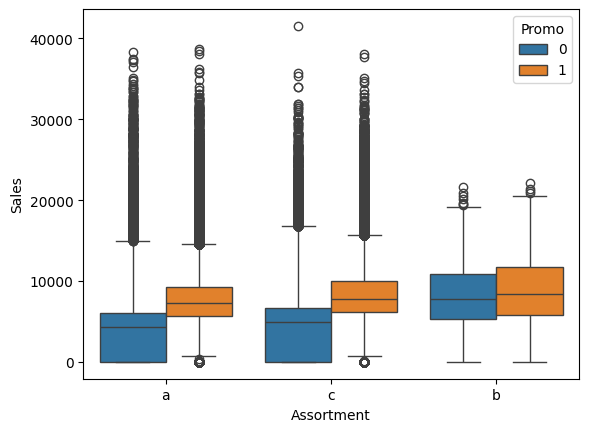

In [ ]:
sns.boxplot(x='Assortment',y='Sales',hue='Promo',data=df)
plt.show()


Tukey HSD Post-Hoc Test Results for Assortment and Promo Interaction:
       Multiple Comparison of Means - Tukey HSD, FWER=0.05       
  group1    group2   meandiff  p-adj   lower      upper    reject
-----------------------------------------------------------------
a_Promo_0 a_Promo_1  3585.8006   0.0   3558.513  3613.0881   True
a_Promo_0 b_Promo_0  4202.8355   0.0  4066.1028  4339.5683   True
a_Promo_0 b_Promo_1  4825.3252   0.0  4651.8148  4998.8356   True
a_Promo_0 c_Promo_0    557.458   0.0   532.8034   582.1125   True
a_Promo_0 c_Promo_1  4193.4656   0.0  4165.0284  4221.9028   True
a_Promo_1 b_Promo_0    617.035   0.0   479.6577   754.4122   True
a_Promo_1 b_Promo_1  1239.5247   0.0   1065.506  1413.5434   True
a_Promo_1 c_Promo_0 -3028.3426   0.0 -3056.3516 -3000.3336   True
a_Promo_1 c_Promo_1   607.6651   0.0   576.2751    639.055   True
b_Promo_0 b_Promo_1   622.4897   0.0   402.8679   842.1115   True
b_Promo_0 c_Promo_0 -3645.3776   0.0 -3782.2561  -3508.499   True
b_Pro

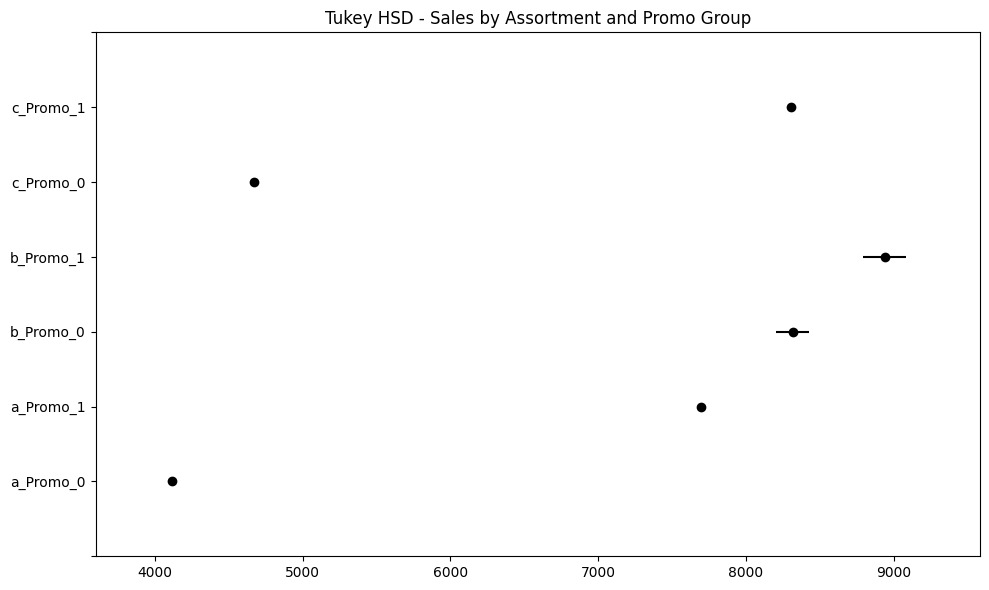

In [ ]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Create a combined group variable for Assortment and Promo interaction
df_anova['Assortment_Promo_Group'] = df_anova['Assortment'].astype(str) + '_Promo_' + df_anova['Promo'].astype(str)

# Perform Tukey HSD post-hoc test
tukey_results = pairwise_tukeyhsd(endog=df_anova['Sales'],
                                  groups=df_anova['Assortment_Promo_Group'],
                                  alpha=0.05)

print("\nTukey HSD Post-Hoc Test Results for Assortment and Promo Interaction:")
print(tukey_results)

# Optionally, visualize the results
tukey_results.plot_simultaneous()
plt.title('Tukey HSD - Sales by Assortment and Promo Group')
plt.tight_layout()
plt.show()

### Interpretation of Tukey HSD Post-Hoc Test Results:

*   The table above displays pairwise comparisons between all possible combinations of 'Assortment' and 'Promo' groups.
*   **`meandiff`**: The difference between the means of the two groups being compared.
*   **`p-adj`**: The adjusted p-value for the comparison. If this value is less than your chosen alpha (e.g., 0.05), it indicates a statistically significant difference between the two group means.
*   **`lower`** and **`upper`**: The lower and upper bounds of the confidence interval for the mean difference.
*   **`reject`**: A boolean value (True/False) indicating whether the null hypothesis (that the means are equal) is rejected for that specific pair.

Look for the comparisons involving `Assortment_Promo_Group` that include 'b_Promo_1' to see if its average sales are significantly higher than other groups, which aligns with your initial claim.


Tukey HSD Post-Hoc Test Results for StoreType and Assortment Interaction:
              Multiple Comparison of Means - Tukey HSD, FWER=0.05              
    group1         group2       meandiff  p-adj     lower       upper    reject
-------------------------------------------------------------------------------
a_Assortment_a a_Assortment_c    912.0087    0.0    879.3074      944.71   True
a_Assortment_a b_Assortment_a   5422.7615    0.0   5276.8219   5568.7011   True
a_Assortment_a b_Assortment_b   3155.0737    0.0   3024.6342   3285.5132   True
a_Assortment_a b_Assortment_c   12570.698    0.0  12187.6817  12953.7142   True
a_Assortment_a c_Assortment_a     248.316    0.0    199.9186    296.7134   True
a_Assortment_a c_Assortment_c    406.9239    0.0    357.0518     456.796   True
a_Assortment_a d_Assortment_a    -80.9724    0.0   -121.1125    -40.8323   True
a_Assortment_a d_Assortment_c    427.5494    0.0    394.5451    460.5536   True
a_Assortment_c b_Assortment_a   4510.7528    

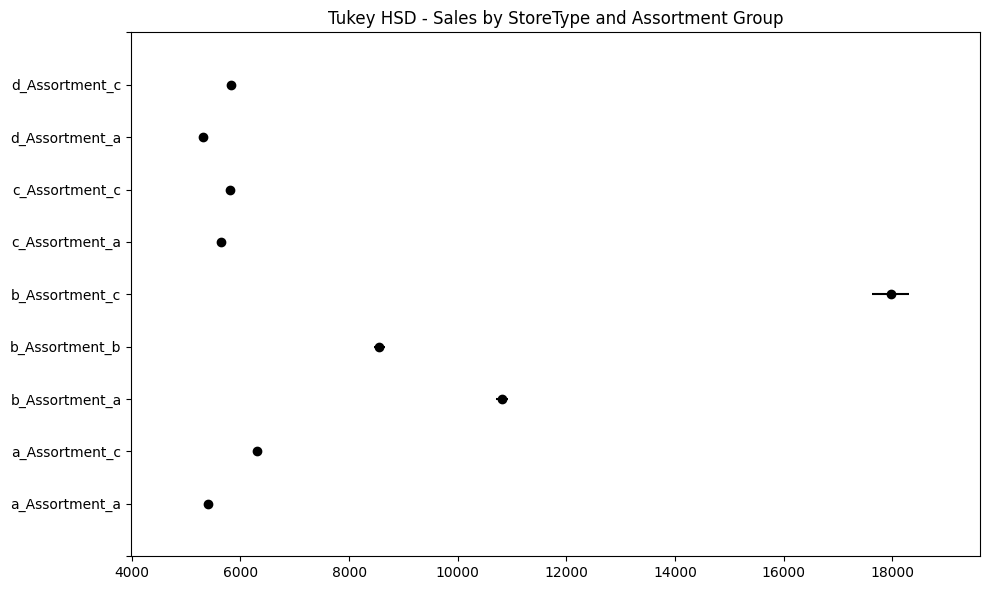

In [ ]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Create a combined group variable for Assortment and Promo interaction
#df_anova['StoreType_Assortment_Group'] = df_anova['Assortment'].astype(str) + '_StoreType_' + df_anova['Promo'].astype(str)

df_anova['StoreType_Assortment_Group'] = df_anova['StoreType'].astype(str) + '_Assortment_' + df_anova['Assortment'].astype(str)

# Perform Tukey HSD post-hoc test
tukey_results = pairwise_tukeyhsd(endog=df_anova['Sales'],
                                  groups=df_anova['StoreType_Assortment_Group'],
                                  alpha=0.05)

print("\nTukey HSD Post-Hoc Test Results for StoreType and Assortment Interaction:")
print(tukey_results)

# Optionally, visualize the results
tukey_results.plot_simultaneous()
plt.title('Tukey HSD - Sales by StoreType and Assortment Group')
plt.tight_layout()
plt.show()

In [ ]:
df_anova.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Assortment_Promo_Group
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,No Promo,a_Promo_1
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct",a_Promo_1
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct",a_Promo_1
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,No Promo,c_Promo_1
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,No Promo,a_Promo_1


In [ ]:
df.groupby(['Store', 'DayOfWeek'])['Sales'].mean()

Store  DayOfWeek
1      1            4946.119403
       2            4650.918519
       3            4454.474074
       4            4094.607407
       5            4516.414815
                       ...     
1115   3            5666.155556
       4            5396.607407
       5            6208.881481
       6            6773.388060
       7               0.000000
Name: Sales, Length: 7805, dtype: float64

In [ ]:
df.groupby(['Store', 'DayOfWeek'])['Sales'].mean().unstack()

DayOfWeek,1,2,3,4,5,6,7
Store,,,,,,,
1,4946.119403,4650.918519,4454.474074,4094.607407,4516.414815,4942.970149,0.0
2,5790.522388,5329.429630,5705.281481,4673.103704,4462.051852,2873.104478,0.0
3,7965.029851,7588.214815,6973.688889,6371.244444,6820.222222,4434.641791,0.0
4,10365.686567,9340.200000,8721.762963,8535.222222,9049.503704,10113.447761,0.0
5,5834.880597,5071.844444,5019.044444,4431.429630,4606.155556,2079.104478,0.0
...,...,...,...,...,...,...,...
1111,6670.328358,5632.162963,5000.866667,4681.303704,5104.651852,3288.723881,0.0
1112,12626.313433,10131.555556,9540.637037,8879.466667,9455.659259,8592.388060,0.0
1113,7006.656716,6512.562963,6308.622222,6570.962963,6293.859259,5893.574627,0.0


## Paired T-test: Average Sales on Monday vs. Tuesday for Each Store

We will compare the average sales for each store on Monday (Day 1) with their average sales on Tuesday (Day 2) using a paired t-test. This helps determine if there's a significant difference in sales performance between these two days for the same set of stores.

In [ ]:
from scipy import stats

# Calculate average sales for each store on each day of the week
store_weekday_sales_avg = df.groupby(['Store', 'DayOfWeek'])['Sales'].mean().unstack()

# Select sales for Monday (Day 1) and Tuesday (Day 2)
# Make sure to drop rows where either day has no sales data
sales_monday = store_weekday_sales_avg[1].dropna()
sales_tuesday = store_weekday_sales_avg[2].dropna()

# Align the two series based on the 'Store' index to ensure paired data
# This will keep only the stores that have data for both Monday and Tuesday
common_stores = pd.Index.intersection(sales_monday.index, sales_tuesday.index)

sales_monday_paired = sales_monday.loc[common_stores]
sales_tuesday_paired = sales_tuesday.loc[common_stores]

print(f"Number of stores with sales data for both Monday and Tuesday: {len(common_stores)}")

# Perform the paired t-test
t_statistic, p_value = stats.ttest_rel(sales_monday_paired, sales_tuesday_paired)

print(f"\nPaired T-test Results (Average Sales: Monday vs. Tuesday):")
print(f"T-statistic: {t_statistic:.3f}")
print(f"P-value: {p_value:.3e}")

# Interpret the results
alpha = 0.05
if p_value < alpha:
    print(f"\nConclusion: Since the p-value ({p_value:.3e}) is less than the significance level ({alpha}), we reject the null hypothesis. There is a statistically significant difference in average sales between Monday and Tuesday for these stores.")
else:
    print(f"\nConclusion: Since the p-value ({p_value:.3e}) is greater than the significance level ({alpha}), we fail to reject the null hypothesis. There is no statistically significant difference in average sales between Monday and Tuesday for these stores.")

Number of stores with sales data for both Monday and Tuesday: 1115

Paired T-test Results (Average Sales: Monday vs. Tuesday):
T-statistic: 66.968
P-value: 0.000e+00

Conclusion: Since the p-value (0.000e+00) is less than the significance level (0.05), we reject the null hypothesis. There is a statistically significant difference in average sales between Monday and Tuesday for these stores.


### Visualizing the Paired Differences

To further understand the difference, we can visualize the distribution of the differences in average sales between Monday and Tuesday for each store.

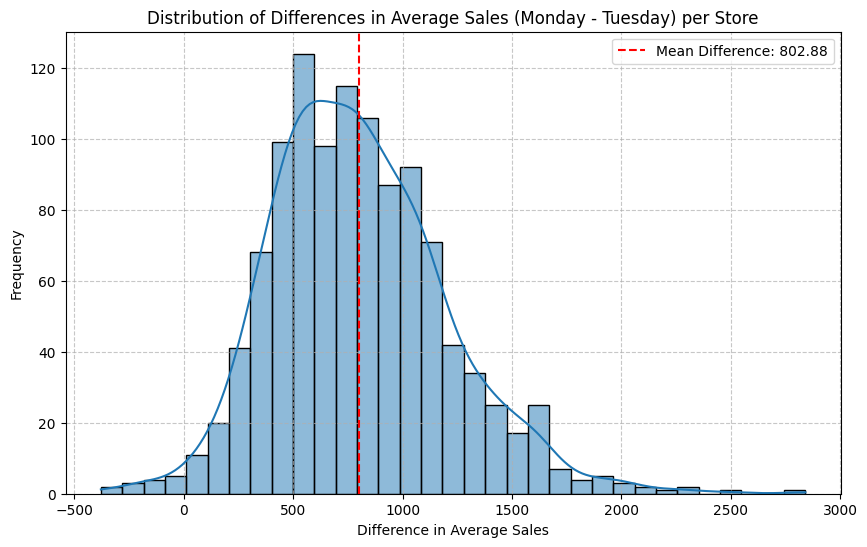

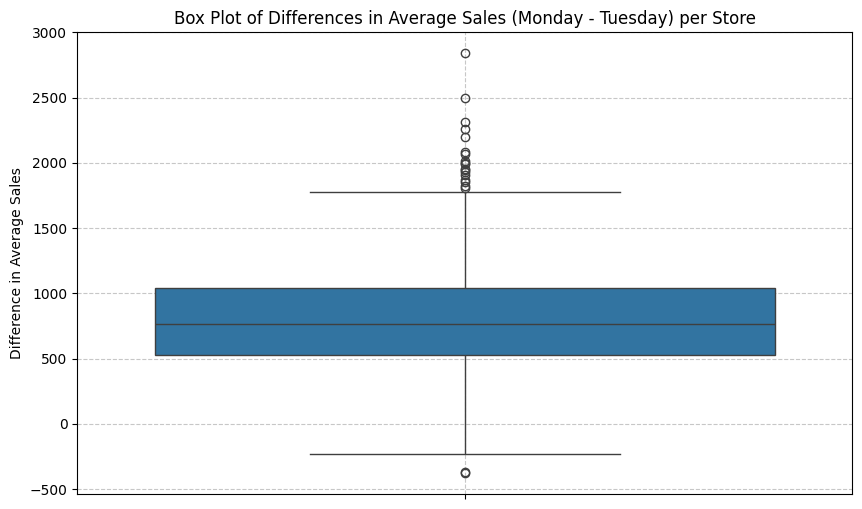

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the differences in average sales for each store
differences = sales_monday_paired - sales_tuesday_paired

plt.figure(figsize=(10, 6))
sns.histplot(differences, kde=True)
plt.title('Distribution of Differences in Average Sales (Monday - Tuesday) per Store')
plt.xlabel('Difference in Average Sales')
plt.ylabel('Frequency')
plt.axvline(differences.mean(), color='red', linestyle='--', label=f'Mean Difference: {differences.mean():.2f}')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(y=differences)
plt.title('Box Plot of Differences in Average Sales (Monday - Tuesday) per Store')
plt.ylabel('Difference in Average Sales')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
import os
import statsmodels.api as sm

## Phase 1 - Data Understanding

In [ ]:
train=pd.read_csv("train.csv")
test=pd.read_csv("test.csv")
store=pd.read_csv("store.csv")

df=train.merge(store,on="Store",how='left')
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [ ]:
df.shape

(1017209, 18)

In [ ]:
df.drop(columns='Customers',inplace=True)

In [ ]:
df.columns

Index(['Store', 'DayOfWeek', 'Date', 'Sales', 'Open', 'Promo', 'StateHoliday',
       'SchoolHoliday', 'StoreType', 'Assortment', 'CompetitionDistance',
       'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2',
       'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval'],
      dtype='object')

In [ ]:
df.shape

(1017209, 17)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.dtypes

,0
Store,int64
DayOfWeek,int64
Date,object
Sales,int64
Open,int64
Promo,int64
StateHoliday,object
SchoolHoliday,int64
StoreType,object
Assortment,object


In [ ]:
# get unique values in all the categorical columns

colums = ["Open", "Promo", "StateHoliday", "SchoolHoliday", "StoreType", "Assortment", "Promo2", "PromoInterval"]
for col in colums:
    print(f"Unique values in column '{col}': {df[col].unique()}")

Unique values in column 'Open': [1 0]
Unique values in column 'Promo': [1 0]
Unique values in column 'StateHoliday': ['0' 'a' 'b' 'c']
Unique values in column 'SchoolHoliday': [1 0]
Unique values in column 'StoreType': ['c' 'a' 'd' 'b']
Unique values in column 'Assortment': ['a' 'c' 'b']
Unique values in column 'Promo2': [0 1]
Unique values in column 'PromoInterval': ['NoPromo' 'Jan,Apr,Jul,Oct' 'Feb,May,Aug,Nov' 'Mar,Jun,Sept,Dec']


In [ ]:
# Convert Date column to datetime from object

df['Date'] = df['Date'].astype('datetime64[ns]')
df['Date'].isna().sum()

np.int64(0)

In [ ]:
# convert all values in stateholiday to string

df['StateHoliday'] = df['StateHoliday'].astype(str)

In [ ]:
df.isna().sum()

,0
Store,0
DayOfWeek,0
Date,0
Sales,0
Open,0
Promo,0
StateHoliday,0
SchoolHoliday,0
StoreType,0
Assortment,0


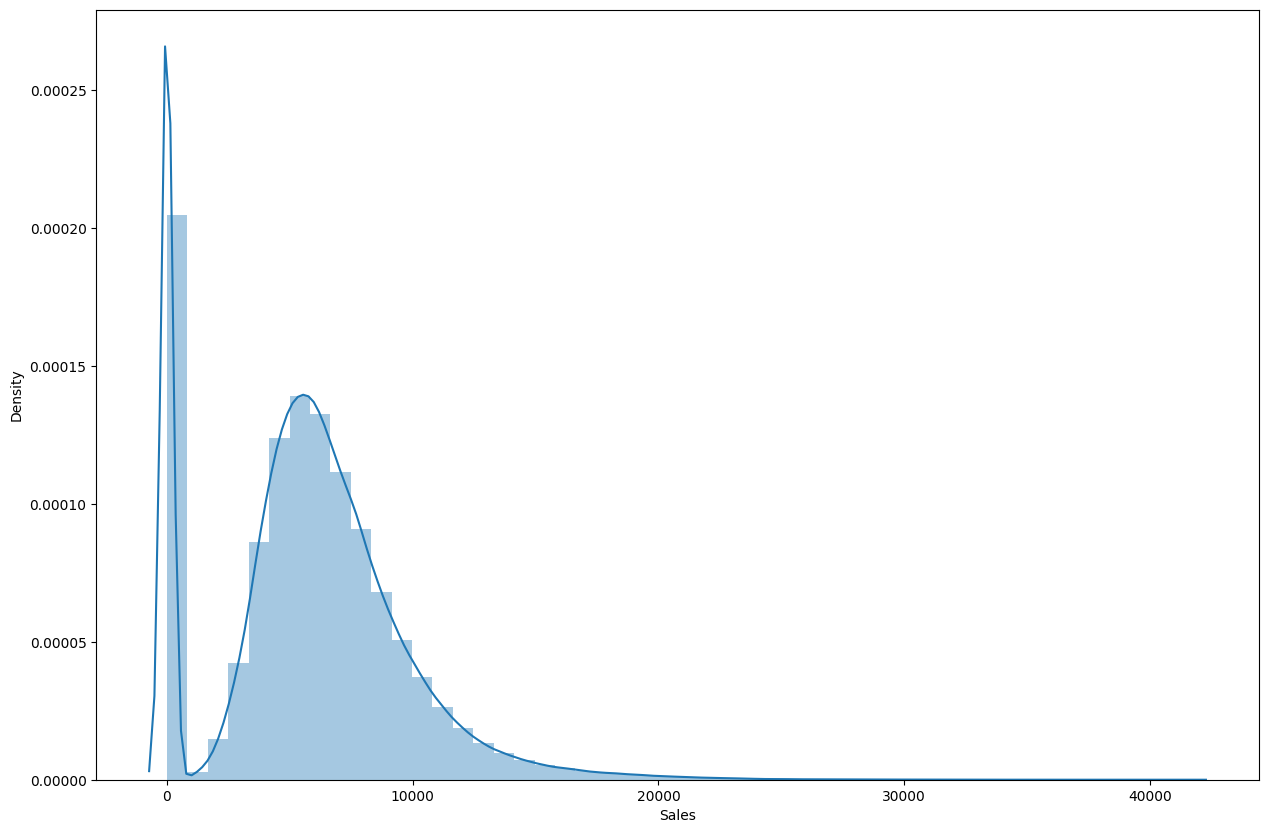

In [ ]:
#Target Distribution (Sales)
plt.figure(figsize=(15,10))
sns.distplot(df['Sales'])
plt.show()

## Phase 2 - Univariate Analysis

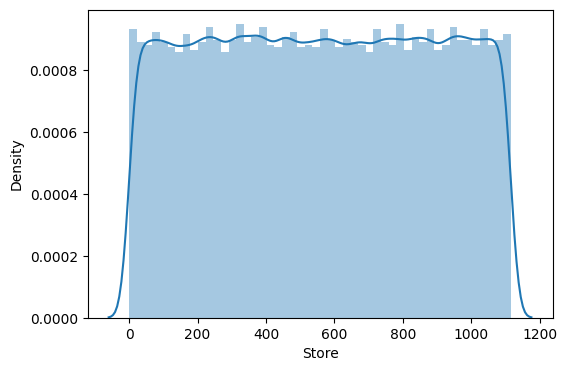

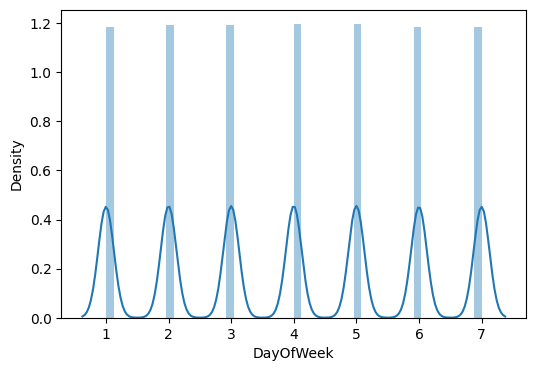

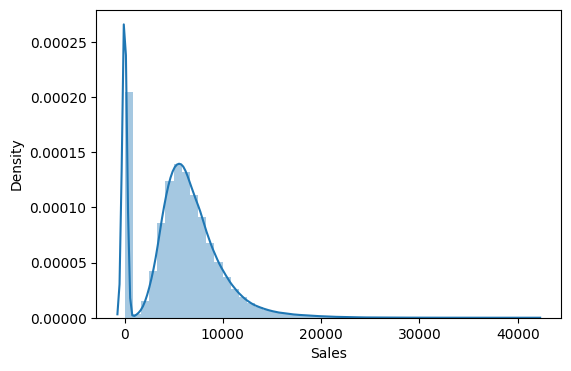

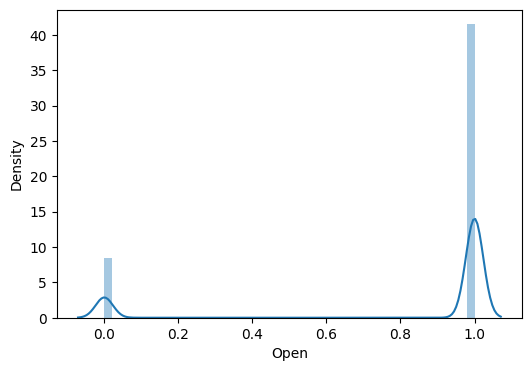

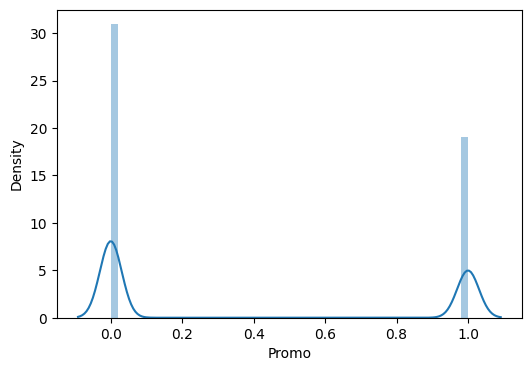

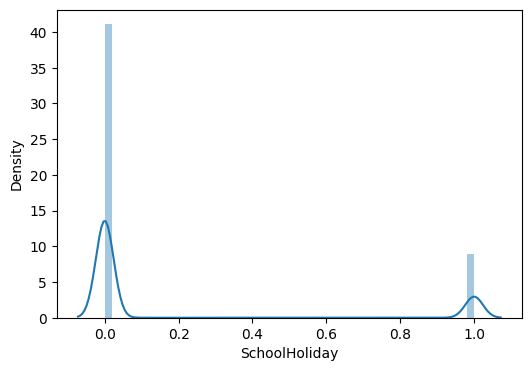

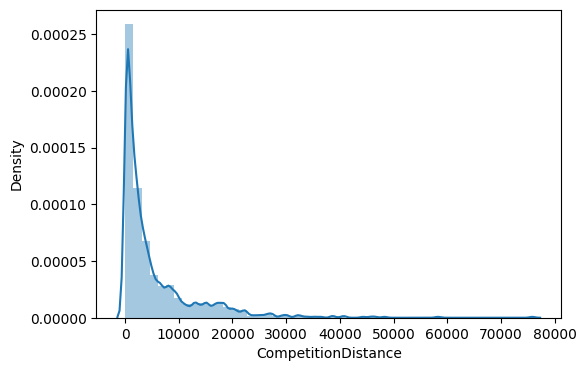

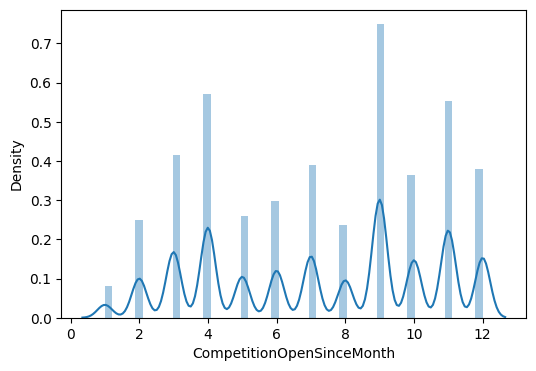

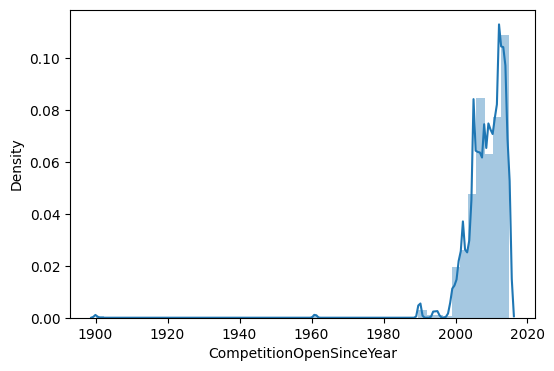

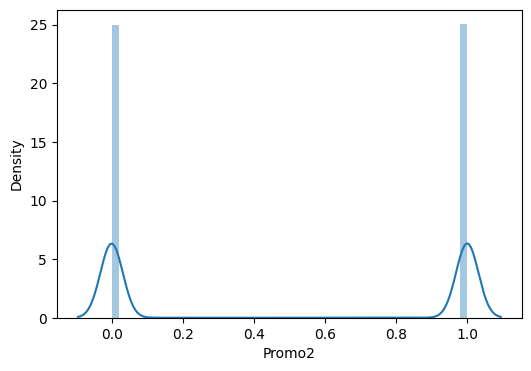

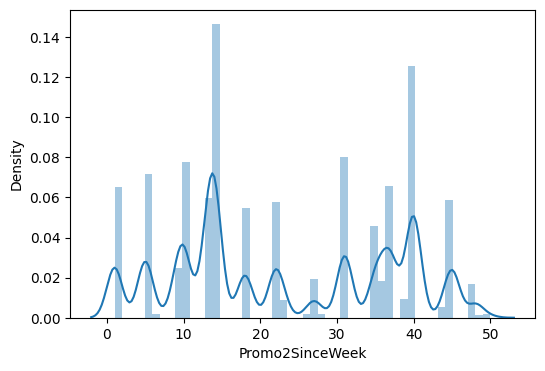

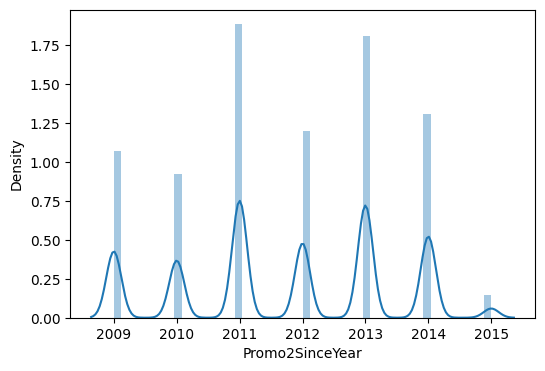

In [ ]:
#univariate Analysis

numeric_df = df.select_dtypes(include='number')

for i in numeric_df:
    plt.figure(figsize=(6,4))
    sns.distplot(df[i])

    plt.show()


Distribution for StateHoliday:
StateHoliday
0    986159
a     20260
b      6690
c      4100
Name: count, dtype: int64


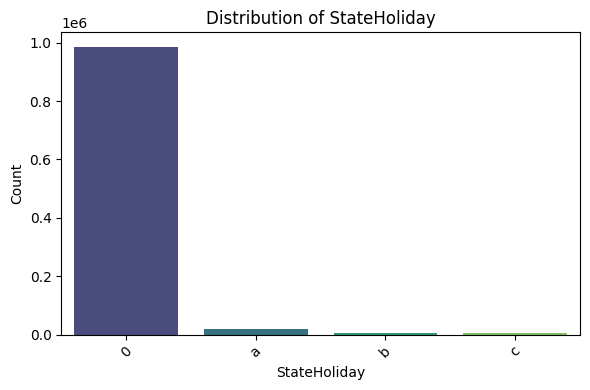


Distribution for StoreType:
StoreType
a    551627
d    312912
c    136840
b     15830
Name: count, dtype: int64


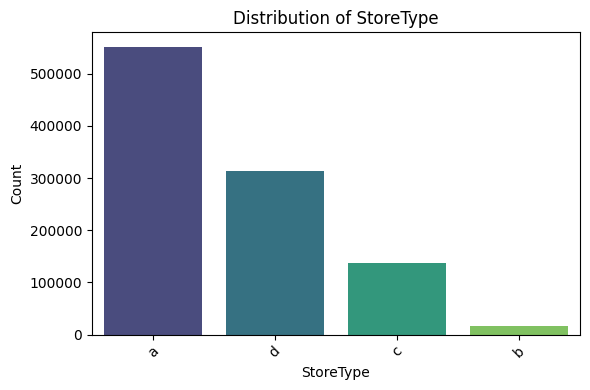


Distribution for Assortment:
Assortment
a    537445
c    471470
b      8294
Name: count, dtype: int64


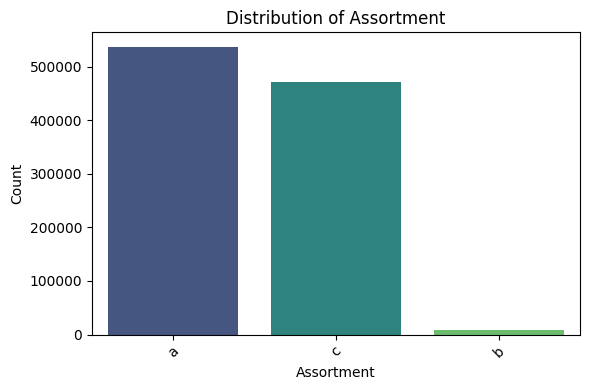


Distribution for PromoInterval:
PromoInterval
Jan,Apr,Jul,Oct     293122
Feb,May,Aug,Nov     118596
Mar,Jun,Sept,Dec     97460
Name: count, dtype: int64


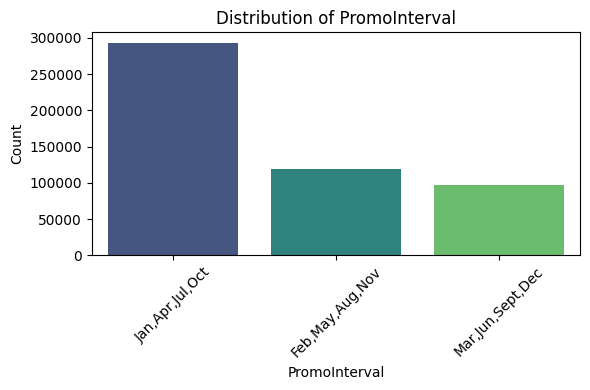

In [ ]:
# Categorical Distribution,

#set the plot on x axis

categorical_cols = df.select_dtypes(include=['object', 'category']).columns

# 2. Loop through and plot each distribution
for col in categorical_cols:
    plt.figure(figsize=(6, 4))

    # Get and print value distributions to console
    print(f"\nDistribution for {col}:")
    print(df[col].value_counts())

    # Generate the bar plot
    sns.countplot(x=col, data=df, order=df[col].value_counts().index, palette='viridis')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45) # Helps if category names are long
    plt.tight_layout()
    plt.show()


The missing vales in the each of the columns is Promo2SinceYear              508031
Promo2SinceWeek              508031
PromoInterval                508031
CompetitionOpenSinceMonth    323348
CompetitionOpenSinceYear     323348
CompetitionDistance            2642
dtype: int64


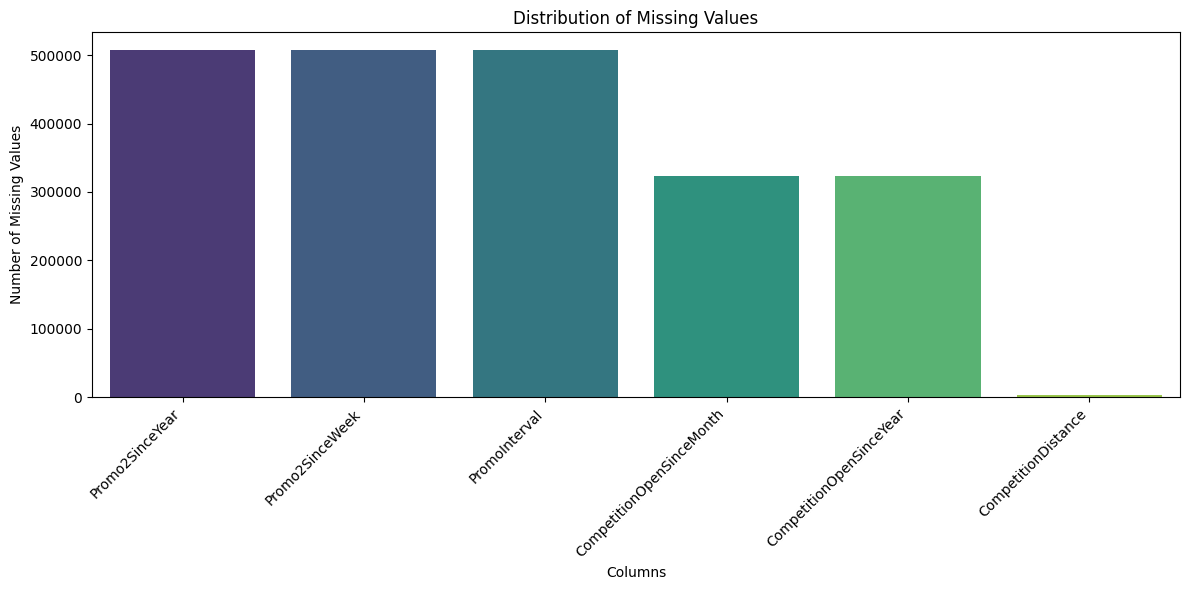

In [ ]:
#distribution of the missing values in the data
missing_values = df.isna().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)
print("The missing vales in the each of the columns is",missing_values)

plt.figure(figsize=(12, 6))
sns.barplot(x=missing_values.index, y=missing_values.values, palette='viridis')
plt.title('Distribution of Missing Values')
plt.xlabel('Columns')
plt.ylabel('Number of Missing Values')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

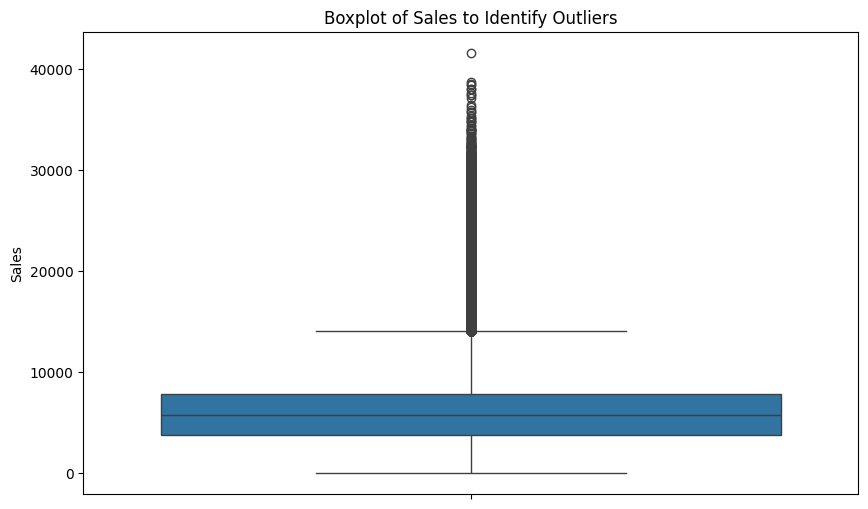

In [ ]:
# Outliers in the df['Sales]

plt.figure(figsize=(10, 6))
sns.boxplot(y=df['Sales'])
plt.title('Boxplot of Sales to Identify Outliers')
plt.ylabel('Sales')
plt.show()

### Understanding the Boxplot and IQR

The box in the boxplot (generated previously) represents the Interquartile Range (IQR). This means:

*   **The bottom edge of the box** is the 25th percentile (Q1).
*   **The top edge of the box** is the 75th percentile (Q3).
*   **The length of the box** is the IQR (Q3 - Q1), which is the range containing the middle 50% of the data.
*   **The line inside the box** is the median (50th percentile).
*   **The 'whiskers'** extend to 1.5 times the IQR from Q1 and Q3, or to the last data point within this range. Any points beyond the whiskers are considered outliers and are plotted individually.

In [ ]:
print(df['Sales'].describe())

count    1.017209e+06
mean     5.773819e+03
std      3.849926e+03
min      0.000000e+00
25%      3.727000e+03
50%      5.744000e+03
75%      7.856000e+03
max      4.155100e+04
Name: Sales, dtype: float64


In [ ]:
df_operational = df[df['Sales'] > 0]
print(f"Original DataFrame shape: {df.shape}")
print(f"DataFrame shape after filtering out 0 sales: {df_operational.shape}")

Q1 = df_operational['Sales'].quantile(0.25)
Q3 = df_operational['Sales'].quantile(0.75)
IQR = Q3 - Q1

print(f"Q1 (25th percentile): {Q1}")
print(f"Q3 (75th percentile): {Q3}")
print(f"IQR (Interquartile Range): {IQR}")

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Lower bound for outliers: {lower_bound}")
print(f"Upper bound for outliers: {upper_bound}")

Original DataFrame shape: (1017209, 17)
DataFrame shape after filtering out 0 sales: (844338, 17)
Q1 (25th percentile): 4859.0
Q3 (75th percentile): 8360.0
IQR (Interquartile Range): 3501.0
Lower bound for outliers: -392.5
Upper bound for outliers: 13611.5


In [ ]:
Q1 = df['Sales'].quantile(0.25)
Q3 = df['Sales'].quantile(0.75)
IQR = Q3 - Q1

print(f"Q1 (25th percentile): {Q1}")
print(f"Q3 (75th percentile): {Q3}")
print(f"IQR (Interquartile Range): {IQR}")

Q1 (25th percentile): 3727.0
Q3 (75th percentile): 7856.0
IQR (Interquartile Range): 4129.0


In [ ]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Lower bound for outliers: {lower_bound}")
print(f"Upper bound for outliers: {upper_bound}")

Lower bound for outliers: -2466.5
Upper bound for outliers: 14049.5


## Bivariate Analysis

### Bivariate Analysis: Sales vs. Numerical Variables

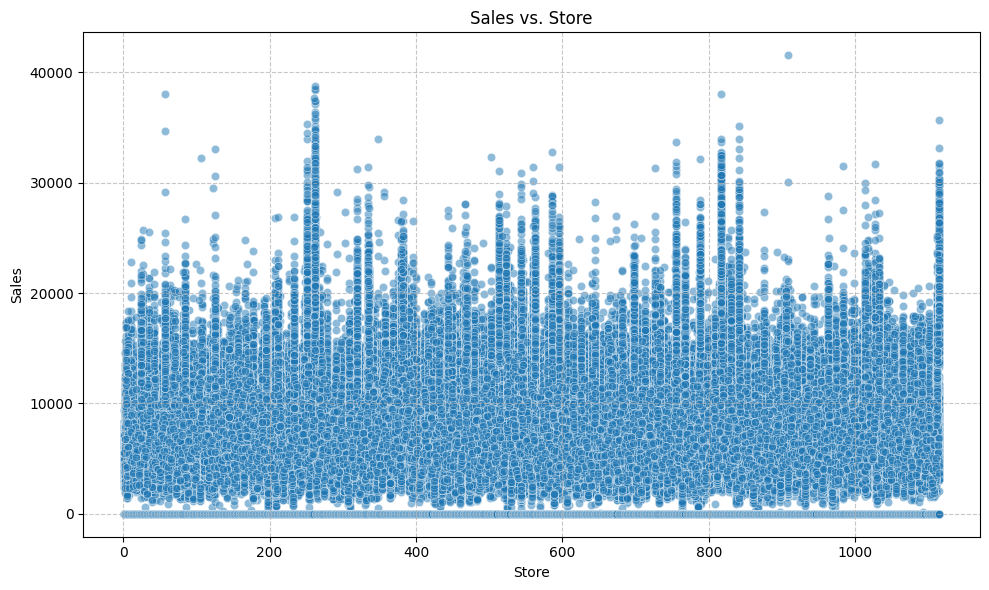

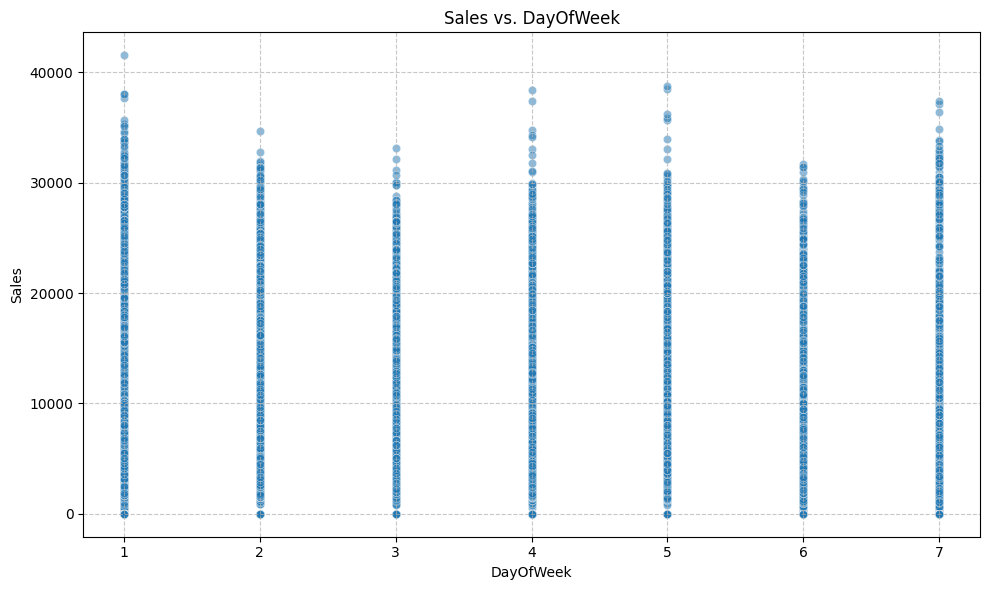

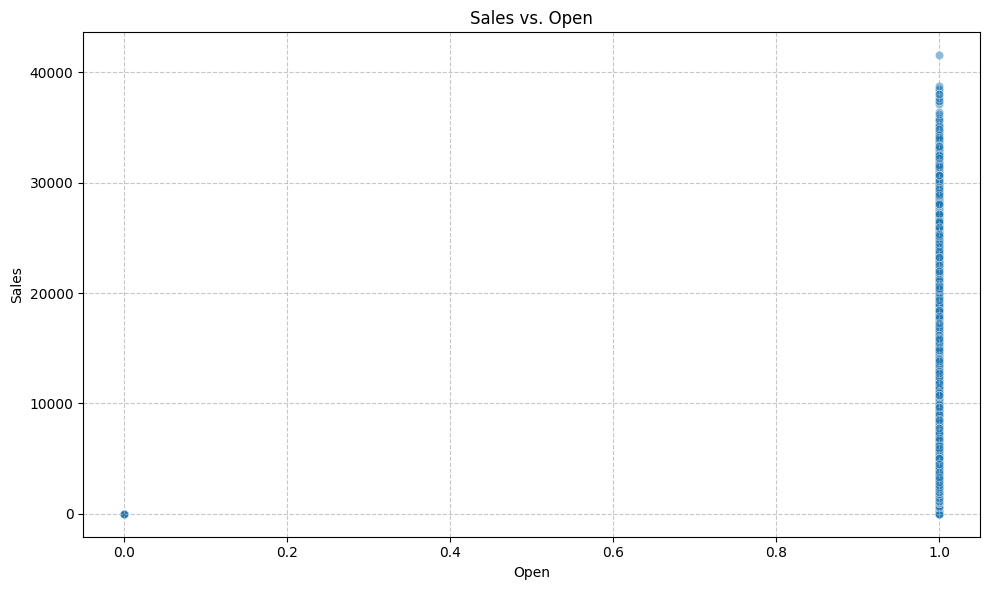

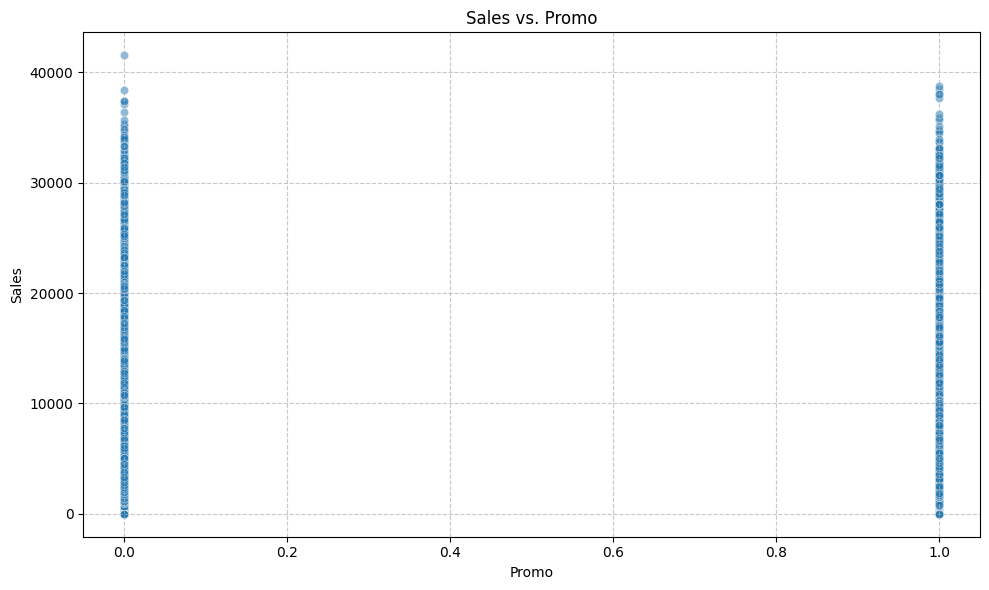

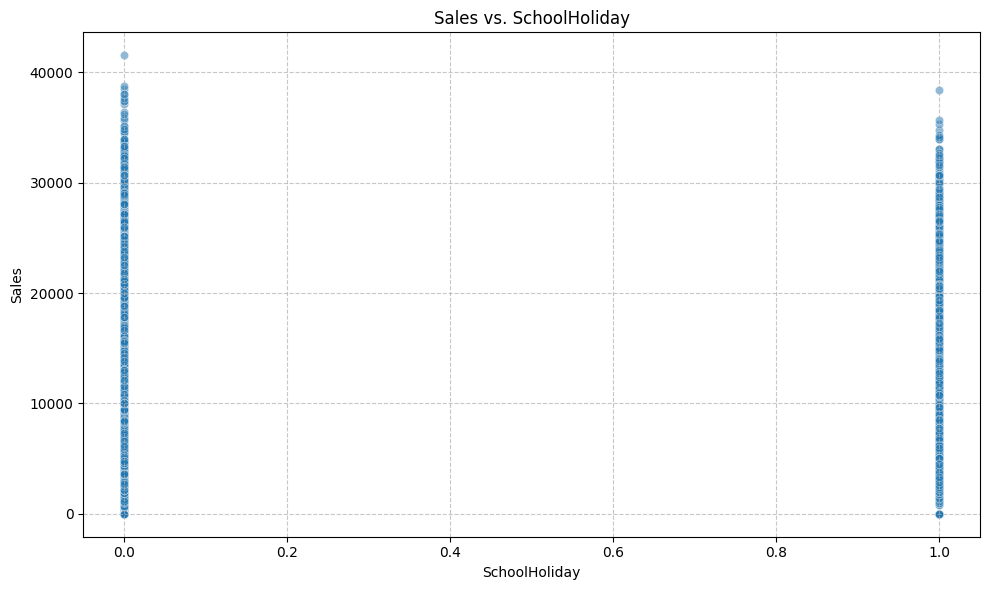

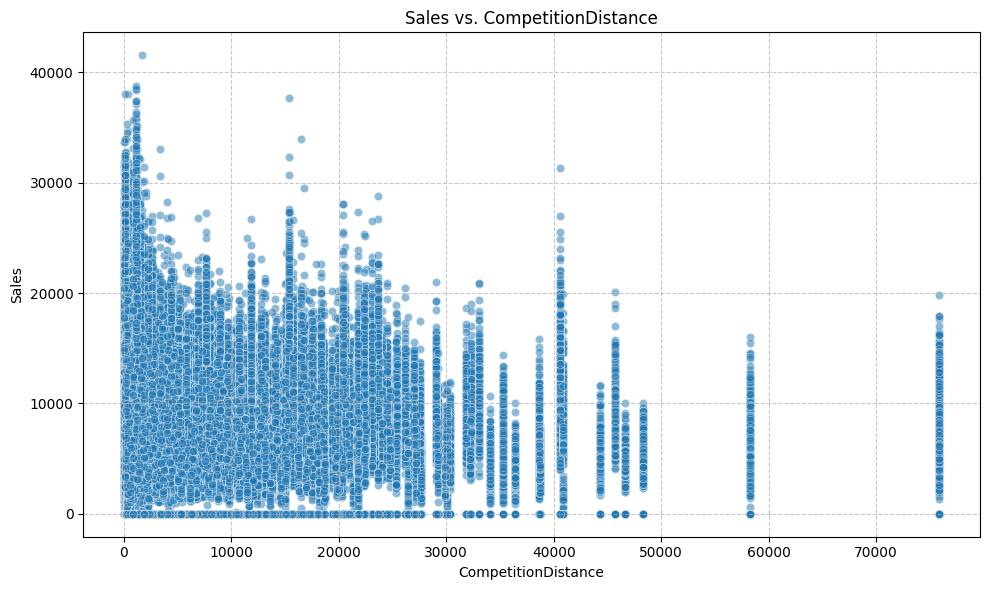

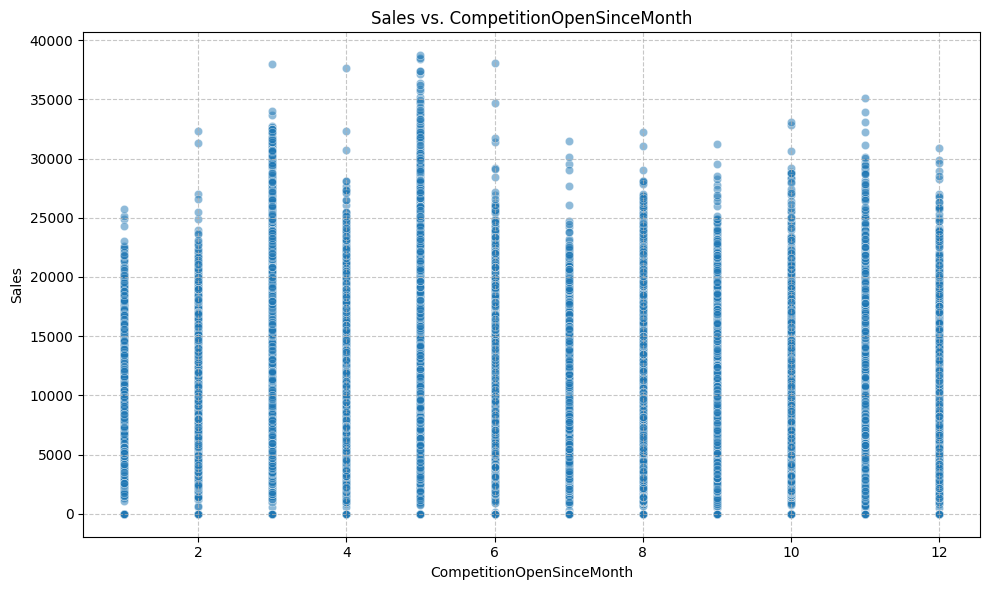

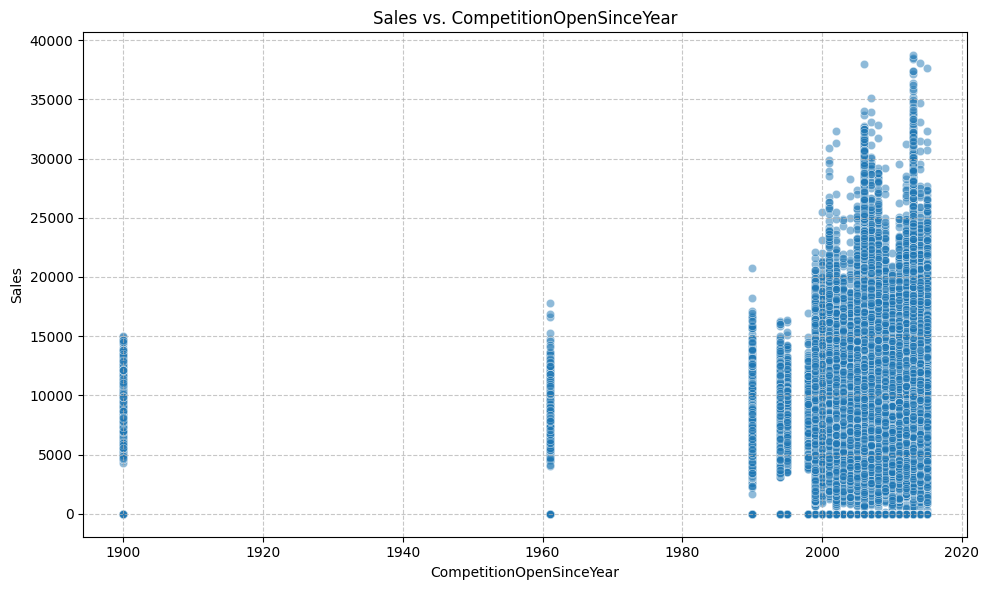

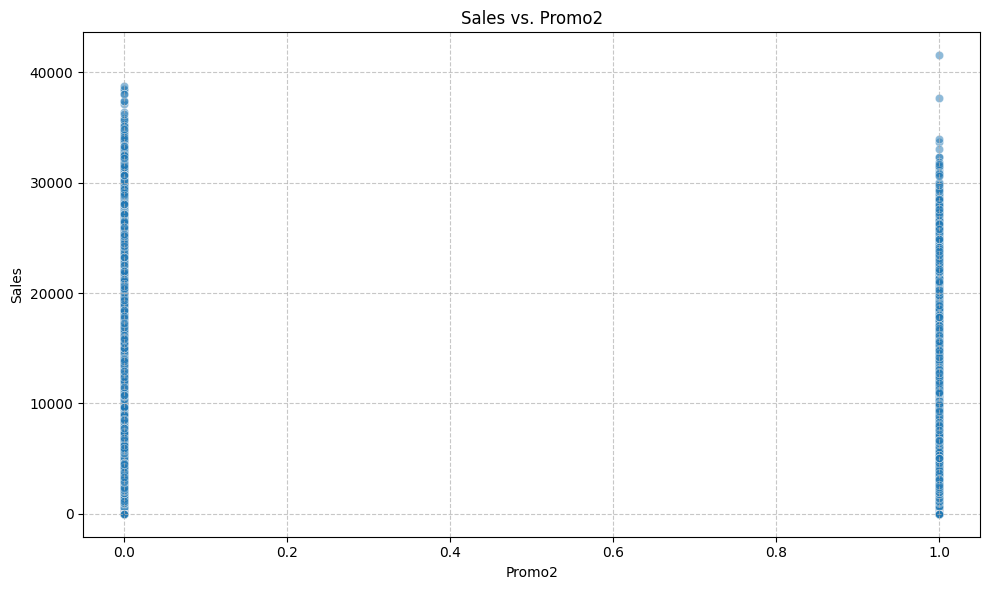

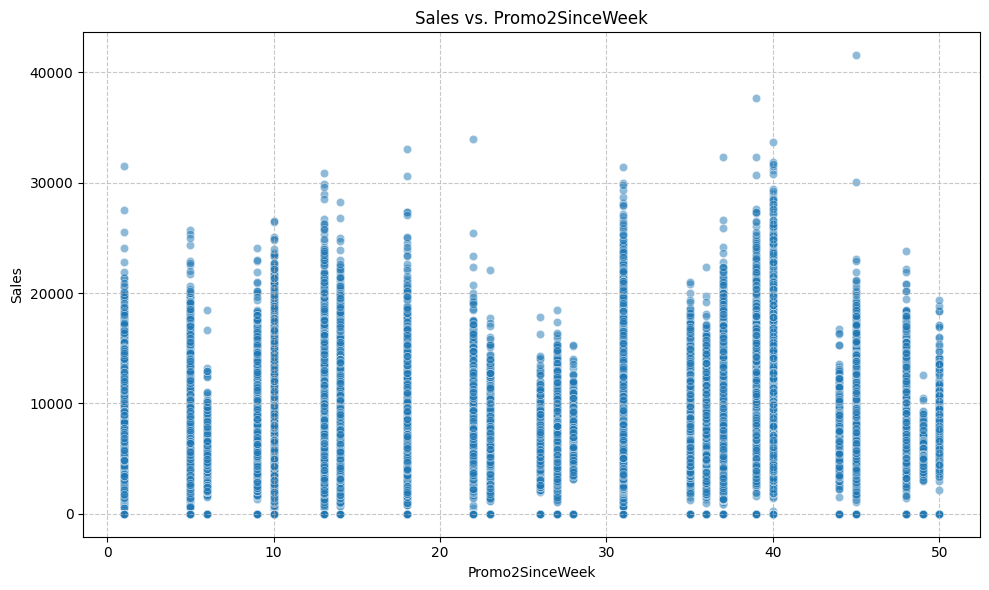

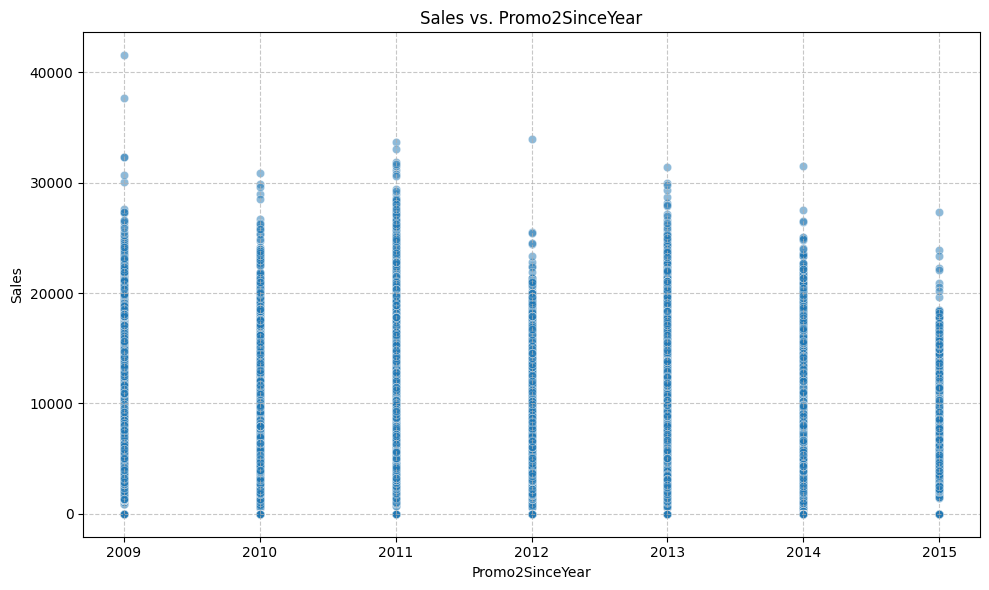

In [ ]:
# Bivariate Analysis: Sales vs. Numerical Variables

numeric_cols_for_bivariate = df.select_dtypes(include=['int64', 'float64']).columns.drop('Sales')

for col in numeric_cols_for_bivariate:
    if col != 'Sales': # Ensure 'Sales' is not plotted against itself
        plt.figure(figsize=(10, 6))
        sns.scatterplot(x=df[col], y=df['Sales'], alpha=0.5)
        plt.title(f'Sales vs. {col}')
        plt.xlabel(col)
        plt.ylabel('Sales')
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()

### Bivariate Analysis: Sales vs. Categorical Variables

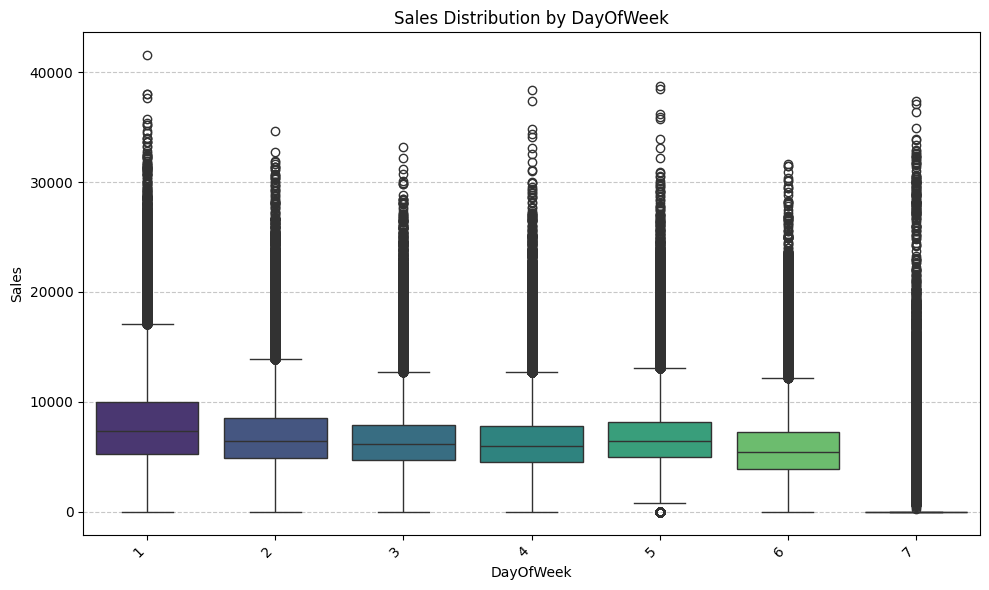

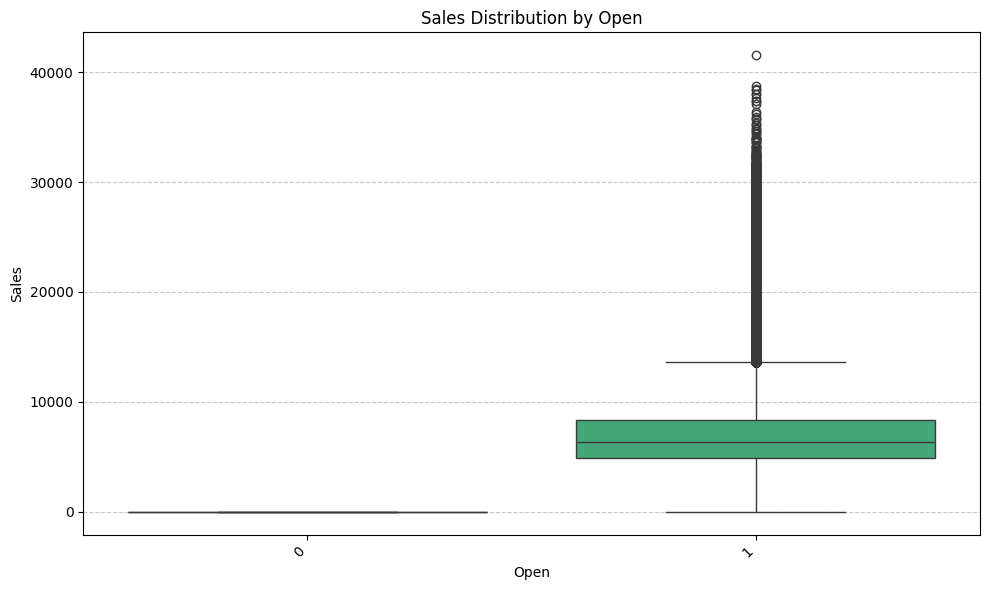

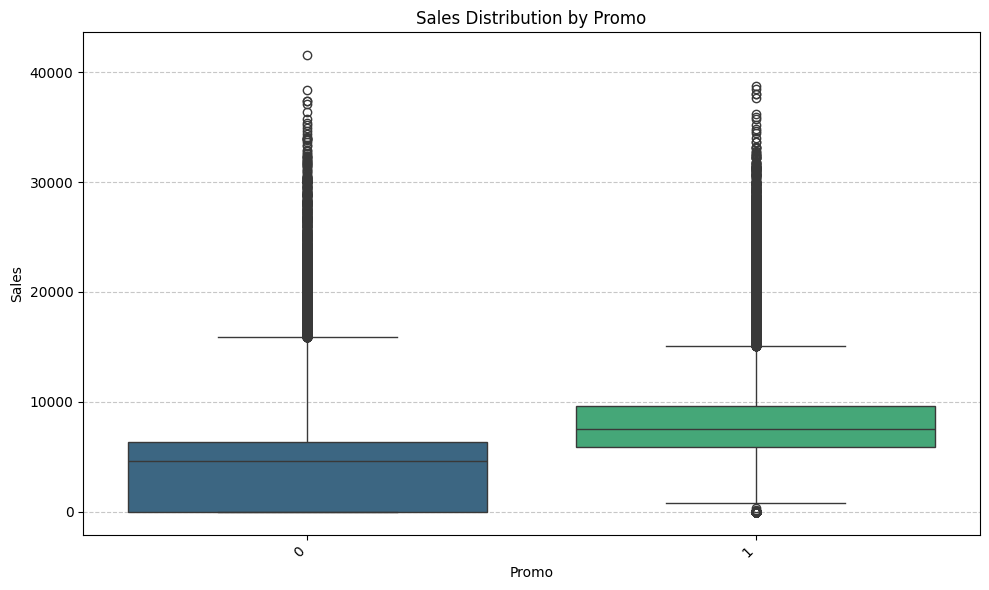

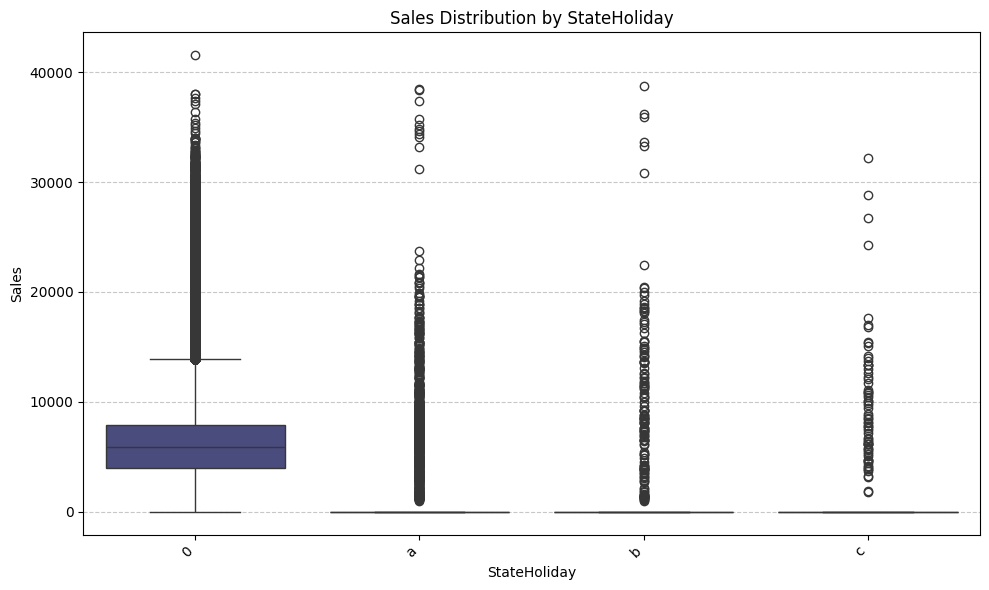

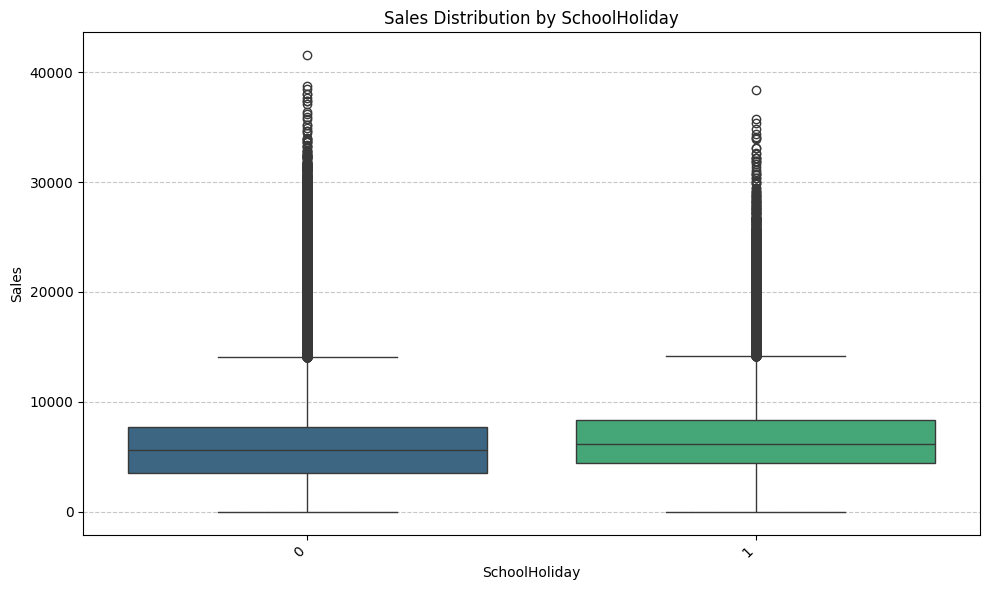

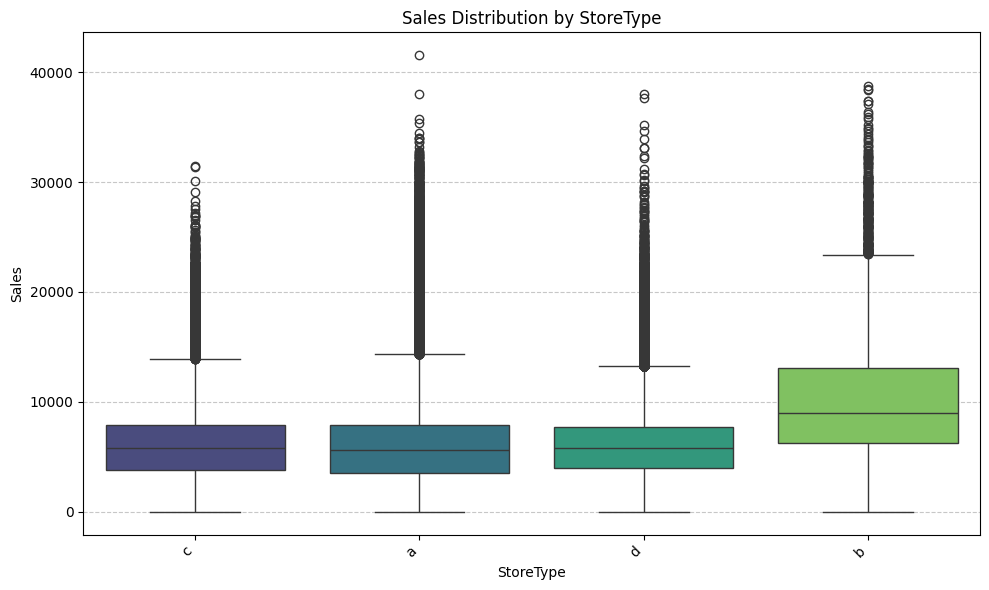

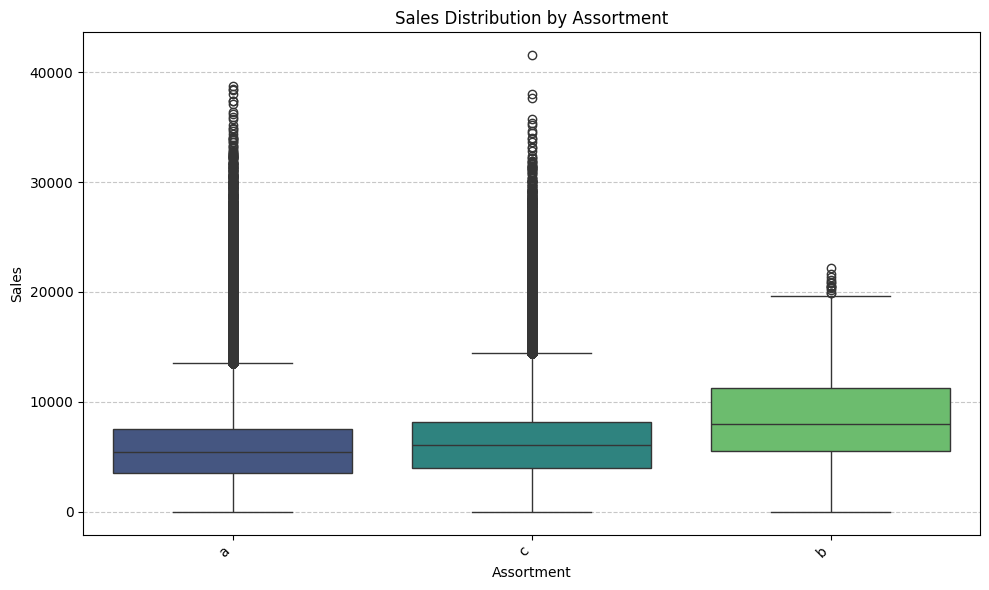

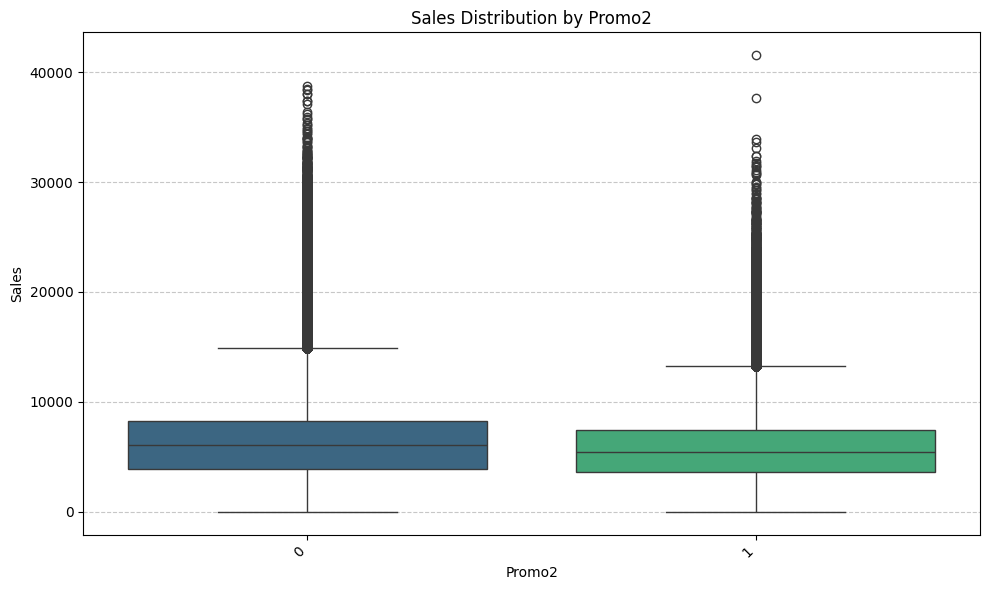

In [ ]:
# Bivariate Analysis: Sales vs. Categorical Variables

categorical_cols_for_bivariate = ['DayOfWeek', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment', 'Promo2']

for col in categorical_cols_for_bivariate:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x=df[col], y=df['Sales'], palette='viridis')
    plt.title(f'Sales Distribution by {col}')
    plt.xlabel(col)
    plt.ylabel('Sales')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

### Bivariate Analysis: Sales vs. Time

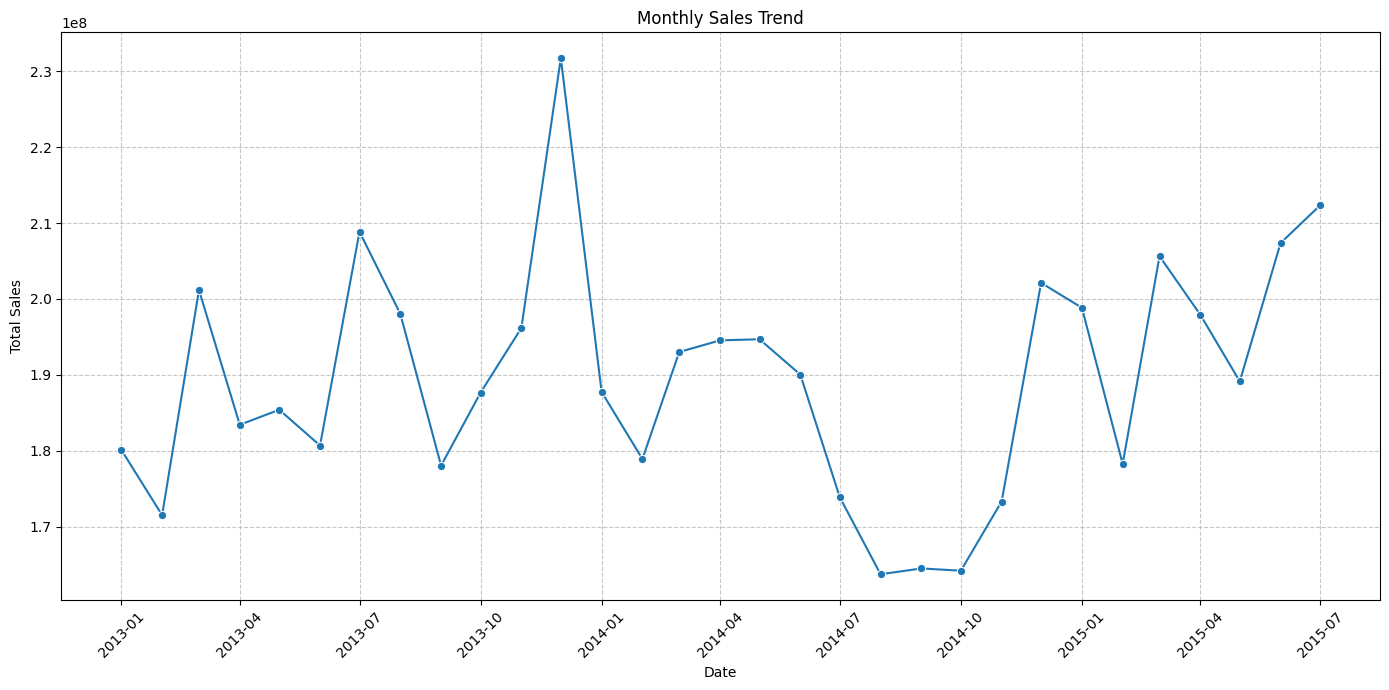

In [ ]:
# Bivariate Analysis: Sales vs. Time

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['WeekOfYear'] = df['Date'].dt.isocalendar().week.astype(int)

# Monthly Sales Trend
monthly_sales = df.groupby(['Year', 'Month'])['Sales'].sum().reset_index()
monthly_sales['Date_Month'] = pd.to_datetime(monthly_sales['Year'].astype(str) + '-' + monthly_sales['Month'].astype(str))

plt.figure(figsize=(14, 7))
sns.lineplot(x='Date_Month', y='Sales', data=monthly_sales, marker='o')
plt.title('Monthly Sales Trend')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Sales by Day of Week (already covered in categorical, but good for time series context)
# sales_by_dayofweek = df_operational.groupby('DayOfWeek')['Sales'].mean().reset_index()
# plt.figure(figsize=(10, 6))
# sns.barplot(x='DayOfWeek', y='Sales', data=sales_by_dayofweek, palette='viridis')
# plt.title('Average Sales by Day of Week')
# plt.xlabel('Day of Week')
# plt.ylabel('Average Sales')
# plt.grid(axis='y', linestyle='--', alpha=0.7)
# plt.tight_layout()
# plt.show()

### Bivariate Analysis: Sales vs. Store-Level Behavior

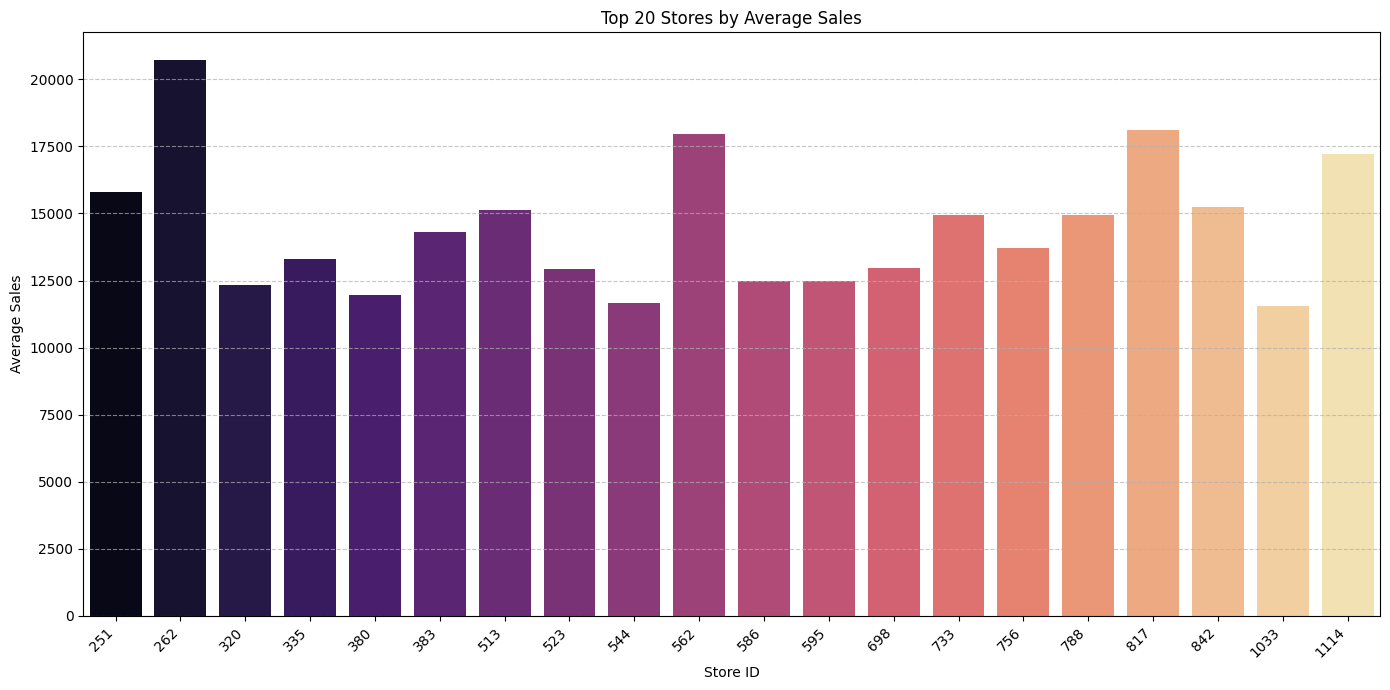

In [ ]:
# Bivariate Analysis: Sales vs. Store-Level Behavior

# Top 20 Stores by Average Sales
store_sales = df.groupby('Store')['Sales'].mean().sort_values(ascending=False).head(20).reset_index()

plt.figure(figsize=(14, 7))
sns.barplot(x='Store', y='Sales', data=store_sales, palette='magma')
plt.title('Top 20 Stores by Average Sales')
plt.xlabel('Store ID')
plt.ylabel('Average Sales')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Bivariate Analysis: Sales vs. Assortment-Level Behavior

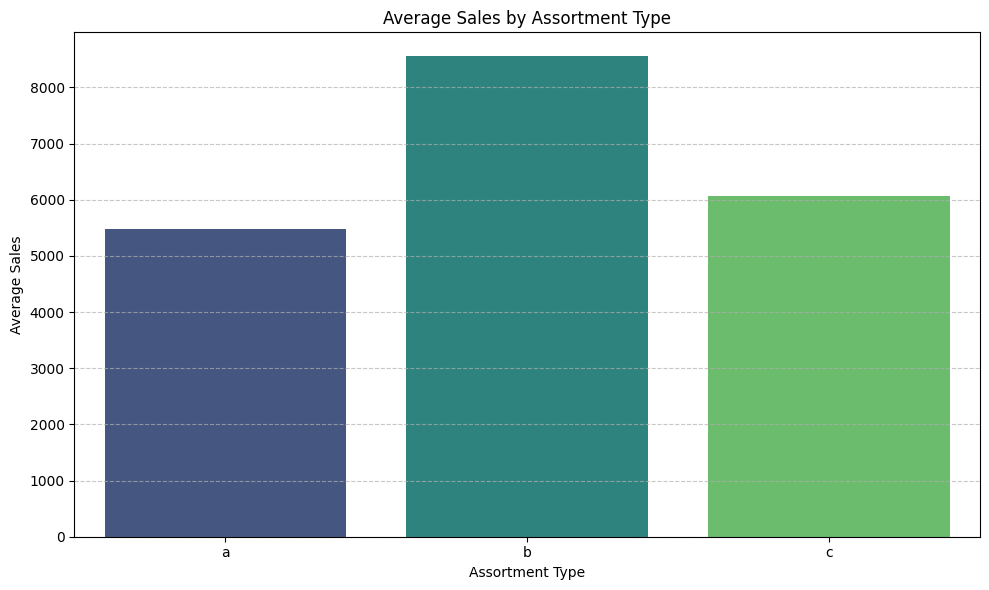

In [ ]:
# Bivariate Analysis: Sales vs. Assortment-Level Behavior

assortment_sales = df.groupby('Assortment')['Sales'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='Assortment', y='Sales', data=assortment_sales, palette='viridis')
plt.title('Average Sales by Assortment Type')
plt.xlabel('Assortment Type')
plt.ylabel('Average Sales')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Statistical Analysis


Correlation Matrix for Numerical Columns:


,Store,DayOfWeek,Sales,Open,Promo,SchoolHoliday,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,WeekOfYear
Store,1.000000,-0.000008,0.005126,-0.000047,0.000058,0.000641,-0.026413,-0.050746,-0.004592,0.008488,0.009865,0.038928,0.001421
DayOfWeek,-0.000008,1.000000,-0.462125,-0.528963,-0.392925,-0.205388,-0.000025,0.000006,-0.000025,0.000168,0.000174,0.000049,-0.004880
Sales,0.005126,-0.462125,1.000000,0.678472,0.452345,0.085124,-0.019229,-0.028257,0.012659,-0.091040,0.059558,-0.021127,0.052946
Open,-0.000047,-0.528963,0.678472,1.000000,0.295042,0.086171,0.007992,0.001384,0.002771,-0.008309,-0.002430,0.001637,0.004792
Promo,0.000058,-0.392925,0.452345,0.295042,1.000000,0.067483,0.000138,-0.000023,0.000152,-0.000983,-0.001008,-0.000283,0.000572
SchoolHoliday,0.000641,-0.205388,0.085124,0.086171,0.067483,1.000000,-0.003689,-0.000526,0.001520,-0.006909,-0.003133,-0.003682,0.071052
CompetitionDistance,-0.026413,-0.000025,-0.019229,0.007992,0.000138,-0.003689,1.000000,-0.061624,0.025397,-0.139886,-0.054384,-0.109695,0.003464
CompetitionOpenSinceMonth,-0.050746,0.000006,-0.028257,0.001384,-0.000023,-0.000526,-0.061624,1.000000,-0.060594,-0.009383,-0.036251,0.050326,-0.000604
CompetitionOpenSinceYear,-0.004592,-0.000025,0.012659,0.002771,0.000152,0.001520,0.025397,-0.060594,1.000000,-0.077336,-0.079784,0.012155,0.003791
Promo2,0.008488,0.000168,-0.091040,-0.008309,-0.000983,-0.006909,-0.139886,-0.009383,-0.077336,1.000000,NaN,NaN,-0.024516


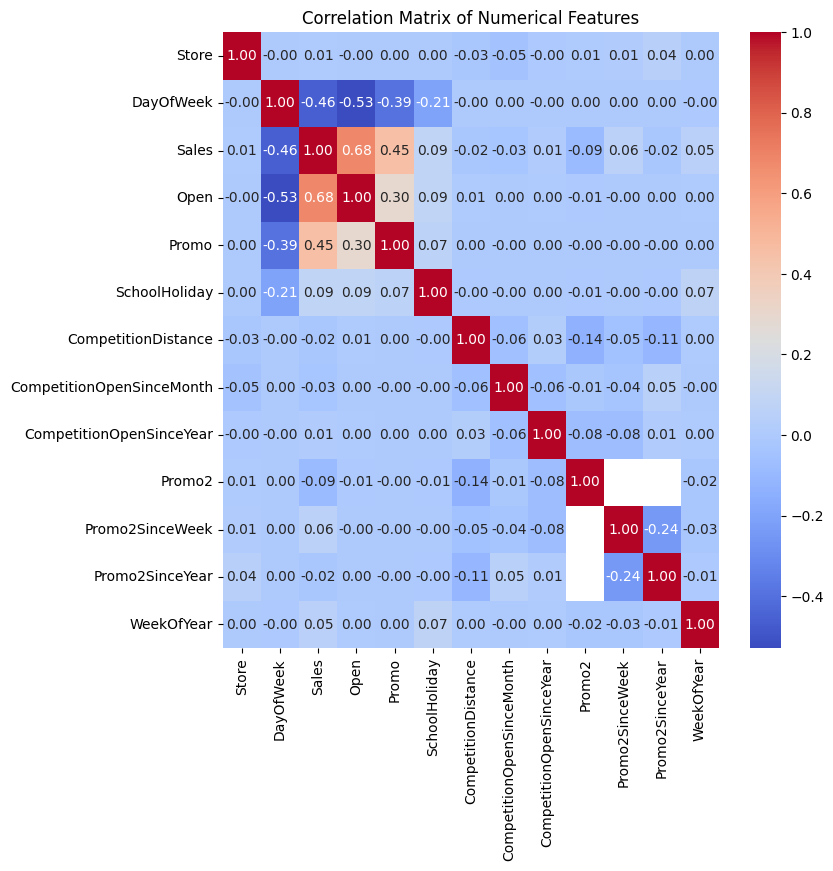

In [ ]:
# Select only numerical columns for correlation matrix
numerical_df = df.select_dtypes(include=['int64', 'float64'])

# Calculate the correlation matrix
correlation_matrix = numerical_df.corr()

# Display the correlation matrix
print("\nCorrelation Matrix for Numerical Columns:")
display(correlation_matrix)

# Optionally, visualize the correlation matrix using a heatmap
plt.figure(figsize=(8, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

In [ ]:
df_2 = df.copy()
df_2.head()

,Store,DayOfWeek,Date,Sales,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,...,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Year,Month,Day,WeekOfYear
0,1,5,2015-07-31,5263,1,1,0,1,c,a,...,9.0,2008.0,0,NaN,NaN,NaN,2015,7,31,31
1,2,5,2015-07-31,6064,1,1,0,1,a,a,...,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct",2015,7,31,31
2,3,5,2015-07-31,8314,1,1,0,1,a,a,...,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct",2015,7,31,31
3,4,5,2015-07-31,13995,1,1,0,1,c,c,...,9.0,2009.0,0,NaN,NaN,NaN,2015,7,31,31
4,5,5,2015-07-31,4822,1,1,0,1,a,a,...,4.0,2015.0,0,NaN,NaN,NaN,2015,7,31,31


## Feature Engineering

In [ ]:
# imputing missing values
df_2['CompetitionDistance'] = df_2['CompetitionDistance'].fillna(df_2['CompetitionDistance'].median())

In [ ]:
df_2['StoreType_Assortment'] = df_2['StoreType'] + '_' + df_2['Assortment']

### Feature Engineering: Encoding Categorical Variables

To prepare categorical features for machine learning models, we need to convert them into a numerical format. One common technique is one-hot encoding, which creates new binary columns for each category. We will apply this to `StateHoliday`, `StoreType`, `Assortment`, and `PromoInterval`.

In [ ]:
#one hot encoding StateHoliday
df_2 = pd.get_dummies(df_2, columns=['StateHoliday'], prefix='StateHoliday')

print("DataFrame after one-hot encoding 'StateHoliday' (first 5 rows):")
display(df_2.head())

DataFrame after one-hot encoding 'StateHoliday' (first 5 rows):


,Store,DayOfWeek,Date,Sales,Open,Promo,SchoolHoliday,StoreType,Assortment,CompetitionDistance,...,PromoInterval,Year,Month,Day,WeekOfYear,StoreType_Assortment,StateHoliday_0,StateHoliday_a,StateHoliday_b,StateHoliday_c
0,1,5,2015-07-31,5263,1,1,1,c,a,1270.0,...,NaN,2015,7,31,31,c_a,True,False,False,False
1,2,5,2015-07-31,6064,1,1,1,a,a,570.0,...,"Jan,Apr,Jul,Oct",2015,7,31,31,a_a,True,False,False,False
2,3,5,2015-07-31,8314,1,1,1,a,a,14130.0,...,"Jan,Apr,Jul,Oct",2015,7,31,31,a_a,True,False,False,False
3,4,5,2015-07-31,13995,1,1,1,c,c,620.0,...,NaN,2015,7,31,31,c_c,True,False,False,False
4,5,5,2015-07-31,4822,1,1,1,a,a,29910.0,...,NaN,2015,7,31,31,a_a,True,False,False,False


### Feature Engineering: Scaling Numerical Variables

`CompetitionDistance` is a numerical feature with a wide range of values. Scaling this feature can improve the performance of many machine learning algorithms. We will use `StandardScaler` to transform `CompetitionDistance` so that it has a mean of 0 and a standard deviation of 1.

In [ ]:
# Scale 'CompetitionDistance'
scaler = StandardScaler()
df_2['CompetitionDistance_Scaled'] = scaler.fit_transform(df_2[['CompetitionDistance']])

print("DataFrame after scaling 'CompetitionDistance' (first 5 rows, with new scaled column):")
display(df_2[['CompetitionDistance', 'CompetitionDistance_Scaled']].head())

DataFrame after scaling 'CompetitionDistance' (first 5 rows, with new scaled column):


,CompetitionDistance,CompetitionDistance_Scaled
0,1270.0,-0.538742
1,570.0,-0.629569
2,14130.0,1.129891
3,620.0,-0.623082
4,29910.0,3.177404


### Feature Engineering: Creating Dummies for `StoreType`, `Assortment`, `PromoInterval`

Similarly to `StateHoliday`, `StoreType`, `Assortment`, and `PromoInterval` are nominal categorical variables that need to be converted into a numerical format using one-hot encoding. This ensures that the model can interpret these features correctly.

In [ ]:
# Create dummies for 'StoreType', 'Assortment', 'PromoInterval'
df_2 = pd.get_dummies(df_2, columns=['StoreType', 'Assortment', 'PromoInterval'], prefix=['StoreType', 'Assortment', 'PromoInterval'])

print("DataFrame after creating dummy variables (first 5 rows, with new dummy columns):")
display(df_2.head())

DataFrame after creating dummy variables (first 5 rows, with new dummy columns):


,Store,DayOfWeek,Date,Sales,Open,Promo,SchoolHoliday,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,...,StoreType_a,StoreType_b,StoreType_c,StoreType_d,Assortment_a,Assortment_b,Assortment_c,"PromoInterval_Feb,May,Aug,Nov","PromoInterval_Jan,Apr,Jul,Oct","PromoInterval_Mar,Jun,Sept,Dec"
0,1,5,2015-07-31,5263,1,1,1,1270.0,9.0,2008.0,...,False,False,True,False,True,False,False,False,False,False
1,2,5,2015-07-31,6064,1,1,1,570.0,11.0,2007.0,...,True,False,False,False,True,False,False,False,True,False
2,3,5,2015-07-31,8314,1,1,1,14130.0,12.0,2006.0,...,True,False,False,False,True,False,False,False,True,False
3,4,5,2015-07-31,13995,1,1,1,620.0,9.0,2009.0,...,False,False,True,False,False,False,True,False,False,False
4,5,5,2015-07-31,4822,1,1,1,29910.0,4.0,2015.0,...,True,False,False,False,True,False,False,False,False,False


### Reviewing the DataFrame after Feature Engineering

Let's check the shape and columns of the DataFrame to confirm the new features have been added and the original categorical columns have been removed.

In [ ]:
print(f"New DataFrame shape: {df_2.shape}")
print("New DataFrame columns:")
for col in df_2.columns:
    print(f"- {col}")

New DataFrame shape: (1017209, 33)
New DataFrame columns:
- Store
- DayOfWeek
- Date
- Sales
- Open
- Promo
- SchoolHoliday
- CompetitionDistance
- CompetitionOpenSinceMonth
- CompetitionOpenSinceYear
- Promo2
- Promo2SinceWeek
- Promo2SinceYear
- Year
- Month
- Day
- WeekOfYear
- StoreType_Assortment
- StateHoliday_0
- StateHoliday_a
- StateHoliday_b
- StateHoliday_c
- CompetitionDistance_Scaled
- StoreType_a
- StoreType_b
- StoreType_c
- StoreType_d
- Assortment_a
- Assortment_b
- Assortment_c
- PromoInterval_Feb,May,Aug,Nov
- PromoInterval_Jan,Apr,Jul,Oct
- PromoInterval_Mar,Jun,Sept,Dec


In [ ]:
df.columns

Index(['Store', 'DayOfWeek', 'Date', 'Sales', 'Open', 'Promo', 'StateHoliday',
       'SchoolHoliday', 'StoreType', 'Assortment', 'CompetitionDistance',
       'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2',
       'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval', 'Year', 'Month',
       'Day', 'WeekOfYear'],
      dtype='object')

### Splitting Data and Training a Baseline Decision Tree Model

We'll prepare the data for modeling by defining our features (X) and target (y). The target variable will be `Sales`, and features will include all other relevant numerical and engineered columns. We will then split the data into 80% for training and 20% for testing to evaluate the model's performance on unseen data. Finally, a Decision Tree Regressor will be trained as a baseline model.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Define target and features
y = df_2['Sales']

# Drop non-numeric and target columns from features
X = df_2.drop(columns=['Sales', 'Date', 'CompetitionDistance', 'StoreType_Assortment'])

# Display the columns and shape of the feature set
print("Features (X) columns:")
print(X.columns)
print(f"Features (X) shape: {X.shape}")

# Split the data into training and testing sets (80:20 ratio)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Features (X) columns:
Index(['Store', 'DayOfWeek', 'Open', 'Promo', 'SchoolHoliday',
       'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2',
       'Promo2SinceWeek', 'Promo2SinceYear', 'Year', 'Month', 'Day',
       'WeekOfYear', 'StateHoliday_0', 'StateHoliday_a', 'StateHoliday_b',
       'StateHoliday_c', 'CompetitionDistance_Scaled', 'StoreType_a',
       'StoreType_b', 'StoreType_c', 'StoreType_d', 'Assortment_a',
       'Assortment_b', 'Assortment_c', 'PromoInterval_Feb,May,Aug,Nov',
       'PromoInterval_Jan,Apr,Jul,Oct', 'PromoInterval_Mar,Jun,Sept,Dec'],
      dtype='object')
Features (X) shape: (1017209, 29)
X_train shape: (813767, 29)
X_test shape: (203442, 29)
y_train shape: (813767,)
y_test shape: (203442,)


### Fitting the Decision Tree Regressor

Now, we'll initialize a `DecisionTreeRegressor` model and fit it to our training data (`X_train`, `y_train`). This will create our baseline predictive model.

In [ ]:
# Initialize and train the Decision Tree Regressor
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

print("Decision Tree Regressor trained successfully.")

Decision Tree Regressor trained successfully.


In [ ]:
#train prediction metrics for evaluation

y_train_pred = dt_model.predict(X_train)
mae_train = mean_absolute_error(y_train, y_train_pred)
mse_train = mean_squared_error(y_train, y_train_pred)
rmse_train = np.sqrt(mse_train)
r2_train = r2_score(y_train, y_train_pred)

print(f"Training set metrics:")
print(f"Mean Absolute Error (MAE): {mae_train:.2f}")
print(f"Mean Squared Error (MSE): {mse_train:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_train:.2f}")
print(f"R-squared (R2): {r2_train:.2f}")

Training set metrics:
Mean Absolute Error (MAE): 1.93
Mean Squared Error (MSE): 5373.91
Root Mean Squared Error (RMSE): 73.31
R-squared (R2): 1.00


### Making Predictions and Evaluating the Model

After training, we will use the model to make predictions on the test set (`X_test`). We'll then evaluate these predictions against the actual values (`y_test`) using several common regression metrics: Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R-squared.

In [ ]:
# Make predictions on the test set
y_pred = dt_model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

Mean Absolute Error (MAE): 654.92
Mean Squared Error (MSE): 1291426.25
Root Mean Squared Error (RMSE): 1136.41
R-squared (R2): 0.91


### Feature Importance from Decision Tree

Understanding which features are most important to the model can provide valuable insights into the sales prediction process. Here, we extract and visualize the feature importances from our trained `DecisionTreeRegressor`.

In [ ]:
# Get feature importances
feature_importances = dt_model.feature_importances_

# Create a DataFrame for better visualization
features_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': feature_importances
})

# Sort features by importance
features_df = features_df.sort_values(by='Importance', ascending=False)

# Display the top 10 most important features
print("Top 10 Most Important Features:")
display(features_df.head(10))

Top 10 Most Important Features:


,Feature,Importance
2,Open,0.459882
18,CompetitionDistance_Scaled,0.115665
3,Promo,0.073454
0,Store,0.071157
6,CompetitionOpenSinceYear,0.043103
5,CompetitionOpenSinceMonth,0.038895
1,DayOfWeek,0.036591
12,Day,0.025496
13,WeekOfYear,0.024959
8,Promo2SinceWeek,0.019436


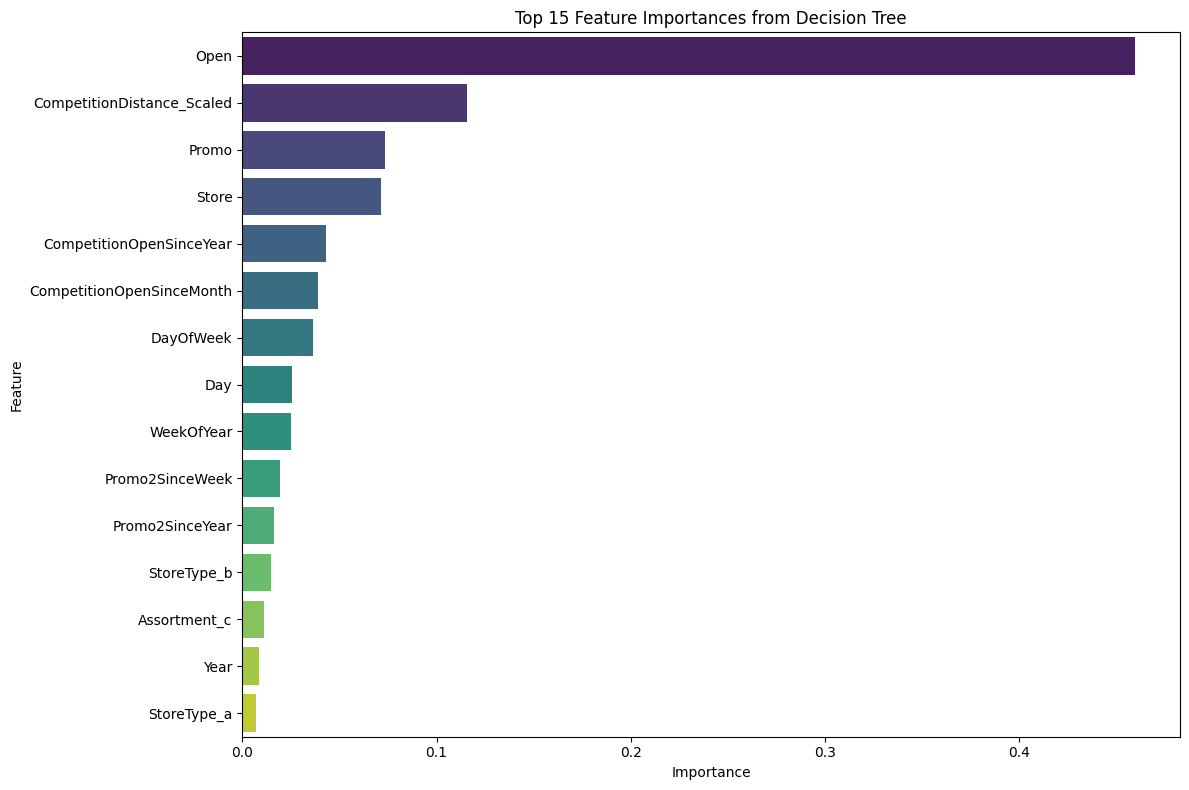

In [ ]:
# Visualize feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=features_df.head(15), palette='viridis')
plt.title('Top 15 Feature Importances from Decision Tree')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### Plotting Actual vs. Predicted Sales

To understand the model's performance more intuitively, we can visualize the relationship between the actual sales values and the sales values predicted by our Decision Tree Regressor. Ideally, points on this plot should fall along a 45-degree line, indicating perfect prediction.

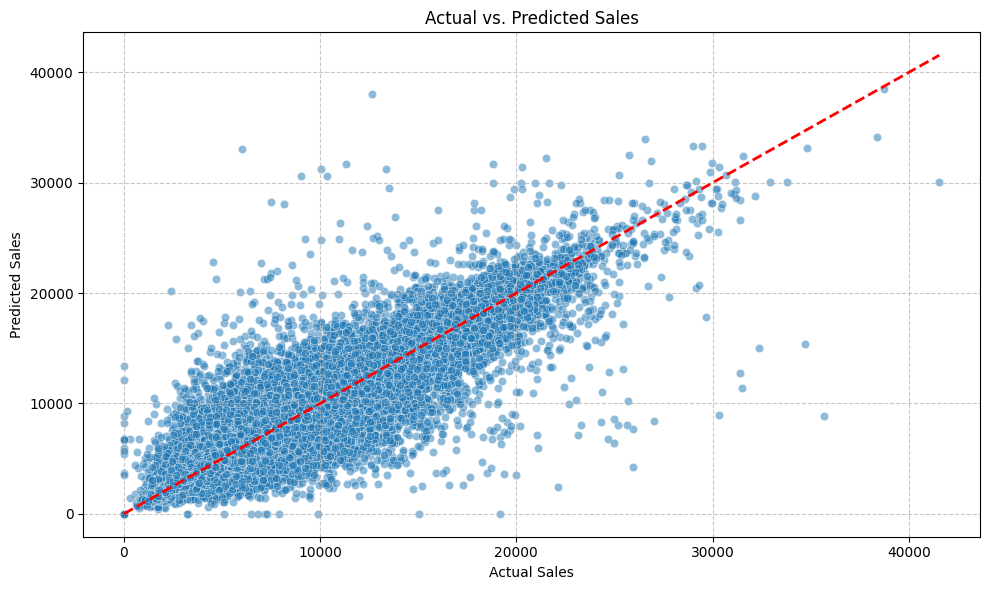

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Ideal line
plt.title('Actual vs. Predicted Sales')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Hyper parameters tuning

### Hyperparameter Tuning for Decision Tree Regressor

To optimize the performance of our `DecisionTreeRegressor`, we will perform hyperparameter tuning. This involves searching for the best combination of parameters that yield the highest performance. We'll use `RandomizedSearchCV` from `sklearn.model_selection` for this purpose, as it offers a good balance between exploration and computational cost compared to `GridSearchCV` for large parameter spaces.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

# Define the parameter distribution for RandomizedSearchCV
param_dist = {
    'max_depth': [10, 20, 30, 40, 50, None], # Max depth of the tree, None means unlimited
    'min_samples_split': [2, 5, 10, 20], # Minimum number of samples required to split an internal node
    'min_samples_leaf': [1, 2, 4, 10], # Minimum number of samples required to be at a leaf node
    'max_features': ['auto', 'sqrt', 'log2', None], # Number of features to consider when looking for the best split
    'splitter': ['best', 'random'] # Strategy used to choose the split at each node
}

# Initialize a Decision Tree Regressor
dt = DecisionTreeRegressor(random_state=42)

# Initialize RandomizedSearchCV
# n_iter: Number of parameter settings that are sampled. Trades off execution time with quality of solution.
# cv: Number of folds for cross-validation.
random_search = RandomizedSearchCV(
    estimator=dt,
    param_distributions=param_dist,
    n_iter=20, # Reduced for quicker execution, can be increased for better results
    cv=3,      # Reduced for quicker execution, can be increased for better results
    verbose=2,
    random_state=42,
    n_jobs=-1, # Use all available cores
    scoring='neg_mean_squared_error' # Optimize for lower MSE
)

print("Starting Randomized Search for optimal Decision Tree hyperparameters...")
random_search.fit(X_train, y_train)
print("Randomized Search completed.")

Starting Randomized Search for optimal Decision Tree hyperparameters...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Randomized Search completed.


### Best Hyperparameters Found

Let's examine the best hyperparameters identified by `RandomizedSearchCV` and the corresponding best score (negative mean squared error).

In [ ]:
# Print the best parameters and the best score
print("Best parameters found: ", random_search.best_params_)
print("Best score (Negative MSE): ", random_search.best_score_)

# Get the best estimator (the retrained model with best parameters)
best_dt_model = random_search.best_estimator_

Best parameters found:  {'splitter': 'best', 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': None, 'max_depth': 50}
Best score (Negative MSE):  -1188638.4529557487


### Evaluate Tuned Decision Tree Model

Now, let's evaluate the performance of the Decision Tree Regressor with the tuned hyperparameters on the test set (`X_test`).

In [ ]:
# Make predictions on the test set using the best model
y_pred_tuned = best_dt_model.predict(X_test)

# Evaluate the tuned model
mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
mse_tuned = mean_squared_error(y_test, y_pred_tuned)
rmse_tuned = np.sqrt(mse_tuned)
r2_tuned = r2_score(y_test, y_pred_tuned)

print(f"Tuned Model Performance on Test Set:")
print(f"Mean Absolute Error (MAE): {mae_tuned:.2f}")
print(f"Mean Squared Error (MSE): {mse_tuned:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_tuned:.2f}")
print(f"R-squared (R2): {r2_tuned:.2f}")

Tuned Model Performance on Test Set:
Mean Absolute Error (MAE): 594.23
Mean Squared Error (MSE): 1057672.76
Root Mean Squared Error (RMSE): 1028.43
R-squared (R2): 0.93


### Hyperparameter Tuning with `ccp_alpha` for Post-Pruning

To further enhance the Decision Tree Regressor's performance and prevent overfitting, we will introduce `ccp_alpha` (cost-complexity pruning parameter) into our hyperparameter tuning process. A higher `ccp_alpha` value increases the number of nodes pruned, potentially leading to a simpler and more robust model.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

# Extend the parameter distribution to include ccp_alpha
param_dist_pruned = {
    'max_depth': [10, 20, 30, 40, 50, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 10],
    'max_features': ['auto', 'sqrt', 'log2', None],
    'splitter': ['best', 'random'],
    'ccp_alpha': np.linspace(0.0, 0.1, 20) # Range for ccp_alpha
}

# Initialize a Decision Tree Regressor
dt_pruned = DecisionTreeRegressor(random_state=42)

# Initialize RandomizedSearchCV with the new parameter distribution
random_search_pruned = RandomizedSearchCV(
    estimator=dt_pruned,
    param_distributions=param_dist_pruned,
    n_iter=30, # Increased n_iter to explore more combinations with ccp_alpha
    cv=5,      # Increased cv for more robust evaluation
    verbose=2,
    random_state=42,
    n_jobs=-1,
    scoring='neg_mean_squared_error'
)

print("Starting Randomized Search for Decision Tree hyperparameters including ccp_alpha...")
random_search_pruned.fit(X_train, y_train)
print("Randomized Search with ccp_alpha completed.")

Starting Randomized Search for Decision Tree hyperparameters including ccp_alpha...
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Randomized Search with ccp_alpha completed.


### Best Hyperparameters Found (with `ccp_alpha`)

Let's review the best hyperparameters and the corresponding score after including `ccp_alpha` in the tuning process.

In [ ]:
# Print the best parameters and the best score
print("Best parameters found (with ccp_alpha): ", random_search_pruned.best_params_)
print("Best score (Negative MSE, with ccp_alpha): ", random_search_pruned.best_score_)

# Get the best estimator
best_dt_model_pruned = random_search_pruned.best_estimator_

Best parameters found (with ccp_alpha):  {'splitter': 'best', 'min_samples_split': 20, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': 30, 'ccp_alpha': np.float64(0.03684210526315789)}
Best score (Negative MSE, with ccp_alpha):  -1217946.729191157


### Evaluate Tuned Decision Tree Model (with `ccp_alpha`)

Finally, we will evaluate the performance of the Decision Tree Regressor with the new, `ccp_alpha`-tuned hyperparameters on the test set.

In [ ]:
# Make predictions on the test set using the best pruned model
y_pred_pruned = best_dt_model_pruned.predict(X_test)

# Evaluate the pruned model
mae_pruned = mean_absolute_error(y_test, y_pred_pruned)
mse_pruned = mean_squared_error(y_test, y_pred_pruned)
rmse_pruned = np.sqrt(mse_pruned)
r2_pruned = r2_score(y_test, y_pred_pruned)

print(f"Pruned Tuned Model Performance on Test Set:")
print(f"Mean Absolute Error (MAE): {mae_pruned:.2f}")
print(f"Mean Squared Error (MSE): {mse_pruned:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_pruned:.2f}")
print(f"R-squared (R2): {r2_pruned:.2f}")

Pruned Tuned Model Performance on Test Set:
Mean Absolute Error (MAE): 617.75
Mean Squared Error (MSE): 1151230.31
Root Mean Squared Error (RMSE): 1072.95
R-squared (R2): 0.92


### Building and Evaluating an XGBoost Regressor Model

Having explored Decision Tree models, let's now build an XGBoost Regressor, a powerful gradient boosting framework, to see if we can achieve better performance. XGBoost is known for its speed and accuracy in various machine learning tasks.

We will train the model on the `X_train` and `y_train` datasets and then evaluate its performance on the `X_test` dataset using the standard regression metrics: Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R-squared.

In [ ]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("Initializing and training XGBoost Regressor...")
# Initialize the XGBoost Regressor
# You can tune these hyperparameters later
xgb_model = xgb.XGBRegressor(
    objective='reg:squarederror', # Objective for regression tasks
    n_estimators=100,             # Number of boosting rounds
    learning_rate=0.1,            # Step size shrinkage to prevent overfitting
    max_depth=5,                  # Maximum depth of a tree
    subsample=0.8,                # Subsample ratio of the training instance
    colsample_bytree=0.8,         # Subsample ratio of columns when constructing each tree
    random_state=42,
    n_jobs=-1                     # Use all available CPU cores
)

# Train the model
xgb_model.fit(X_train, y_train)
print("XGBoost Regressor trained successfully.")

Initializing and training XGBoost Regressor...
XGBoost Regressor trained successfully.


### Evaluating XGBoost Model Performance

Now, let's evaluate the trained XGBoost model on the test set to determine its accuracy and predictive power.

In [ ]:
# Make predictions on the test set
y_pred_xgb = xgb_model.predict(X_test)

# Evaluate the XGBoost model
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"XGBoost Model Performance on Test Set:")
print(f"Mean Absolute Error (MAE): {mae_xgb:.2f}")
print(f"Mean Squared Error (MSE): {mse_xgb:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_xgb:.2f}")
print(f"R-squared (R2): {r2_xgb:.2f}")

XGBoost Model Performance on Test Set:
Mean Absolute Error (MAE): 1309.37
Mean Squared Error (MSE): 3595338.50
Root Mean Squared Error (RMSE): 1896.14
R-squared (R2): 0.76


In [ ]:
test_df = df.copy()
test_df.head()

,Store,DayOfWeek,Date,Sales,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,...,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Year,Month,Day,WeekOfYear
0,1,5,2015-07-31,5263,1,1,0,1,c,a,...,9.0,2008.0,0,0.0,0.0,NoPromo,2015,7,31,31
1,2,5,2015-07-31,6064,1,1,0,1,a,a,...,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct",2015,7,31,31
2,3,5,2015-07-31,8314,1,1,0,1,a,a,...,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct",2015,7,31,31
3,4,5,2015-07-31,13995,1,1,0,1,c,c,...,9.0,2009.0,0,0.0,0.0,NoPromo,2015,7,31,31
4,5,5,2015-07-31,4822,1,1,0,1,a,a,...,4.0,2015.0,0,0.0,0.0,NoPromo,2015,7,31,31


In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler



### Handling remaining missing values for Feature Engineering

For columns related to `CompetitionOpenSinceMonth`, `CompetitionOpenSinceYear`, `Promo2SinceWeek`, and `Promo2SinceYear`, NaN values often indicate that the store does not have a competition opened yet, or Promo2 is not applicable. Therefore, filling these NaN values with 0 is a reasonable approach for numerical features, as it signifies the absence of these events or a default state before they began.

In [ ]:
df['CompetitionOpenSinceMonth'] = df['CompetitionOpenSinceMonth'].fillna(0)
df['CompetitionOpenSinceYear'] = df['CompetitionOpenSinceYear'].fillna(0)
df['Promo2SinceWeek'] = df['Promo2SinceWeek'].fillna(0)
df['Promo2SinceYear'] = df['Promo2SinceYear'].fillna(0)
df['PromoInterval'] = df['PromoInterval'].fillna('NoPromo')

print("Missing values after imputation:")
display(df.isna().sum())

Missing values after imputation:


,0
Store,0
DayOfWeek,0
Date,0
Sales,0
Open,0
Promo,0
StateHoliday,0
SchoolHoliday,0
StoreType,0
Assortment,0


### Feature Selection for Clustering

For K-means clustering, we select numerical features that describe store characteristics and their performance. We will include `Sales`, `CompetitionDistance`, and promotion-related features to identify distinct store segments.

In [ ]:
features_for_clustering = [
    'Sales',
    'CompetitionDistance',
    'CompetitionOpenSinceMonth',
    'CompetitionOpenSinceYear',
    'Promo2',
    'Promo2SinceWeek',
    'Promo2SinceYear'
]

X = df[features_for_clustering]

print(f"Selected features for clustering: {features_for_clustering}")
display(X.head())

Selected features for clustering: ['Sales', 'CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear']


,Sales,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear
0,5263,1270.0,9.0,2008.0,0,0.0,0.0
1,6064,570.0,11.0,2007.0,1,13.0,2010.0
2,8314,14130.0,12.0,2006.0,1,14.0,2011.0
3,13995,620.0,9.0,2009.0,0,0.0,0.0
4,4822,29910.0,4.0,2015.0,0,0.0,0.0


### Data Scaling

K-means is a distance-based algorithm, meaning it is sensitive to the scale of the features. To ensure that all features contribute equally to the distance calculations, we will scale the selected features using `StandardScaler`.

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled features (first 5 rows):")
display(pd.DataFrame(X_scaled, columns=features_for_clustering).head())

Scaled features (first 5 rows):


,Sales,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear
0,-0.132683,-0.539198,0.950877,0.681904,-1.001128,-0.760097,-1.001128
1,0.075373,-0.629927,1.417781,0.680835,0.998873,0.088250,0.997130
2,0.659800,1.127616,1.651232,0.679765,0.998873,0.153507,0.998124
3,2.135414,-0.623446,0.950877,0.682973,-1.001128,-0.760097,-1.001128
4,-0.247231,3.172897,-0.216381,0.689387,-1.001128,-0.760097,-1.001128


### Elbow Method to Determine Optimal K

The Elbow method helps to find the optimal number of clusters (K) for K-means. It involves plotting the Within-Cluster Sum of Squares (WCSS) against the number of clusters. The 'elbow' point in the graph, where the decrease in WCSS slows down, typically indicates the optimal K.

In [ ]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

ValueError: Input X contains NaN.
KMeans does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

### K-Means Clustering with Optimal K and Adding Cluster Labels

Based on the Elbow method plot, an optimal K value (e.g., 3 or 4) can be chosen. For demonstration, let's proceed with K=3. We will then perform K-means clustering with this chosen K and add the resulting cluster labels as a new column to the original DataFrame, which can be used for further segmented analysis or modeling.

In [ ]:
optimal_k = 3 # Based on observing the elbow plot, 3 or 4 seems reasonable.

kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

print(f"DataFrame with new 'Cluster' column (first 5 rows) for K={optimal_k}:")
display(df.head())

### 1. Average Sales per Cluster

To understand the performance of each cluster, we will calculate the average sales for stores within each identified cluster. This helps in characterizing the sales behavior of each segment.

In [ ]:
average_sales_per_cluster = df.groupby('Cluster')['Sales'].mean().reset_index()
print("Average Sales per Cluster:")
display(average_sales_per_cluster)

### 2. Visualize the Clusters on a Scatter Plot

Visualizing the clusters helps to understand their spatial separation and characteristics. We will plot `Sales` against `CompetitionDistance`, colored by cluster, as these are two significant features in our clustering. For better interpretability, we will use the original (unscaled) values for plotting.

In [ ]:
plt.figure(figsize=(12, 8))
sns.scatterplot(x='CompetitionDistance', y='Sales', hue='Cluster', data=df, palette='viridis', s=50, alpha=0.6)
plt.title('K-Means Clusters: Sales vs. CompetitionDistance')
plt.xlabel('Competition Distance')
plt.ylabel('Sales')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

### 3. Compare the Mean of Features Across Clusters

To further characterize each cluster, we will examine the mean of the features that were used for clustering across all identified clusters. This will provide insights into what defines each segment.

In [ ]:
cluster_feature_means = df.groupby('Cluster')[features_for_clustering].mean()
print("Mean of Features Across Clusters:")
display(cluster_feature_means)

# ==========================================
# PART 2: ADVANCED STATS, FEATURE ENGINEERING & XGBOOST MODEL
# ==========================================

## Advanced Statistical Proofs
We apply rigorous mathematical tests across different variable types (Continuous, Binary, Multi-Categorical) to eliminate guesswork and prove our business insights.

In [ ]:
from scipy import stats
import numpy as np
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score

df_open = df[(df['Open'] == 1) & (df['Sales'] > 0)].copy()

print('='*60)
print(' 1. PEARSON CORRELATION (Continuous vs Continuous)')
print('='*60)

corr_cust, p_val_cust = stats.pearsonr(df_open['Customers'], df_open['Sales'])
print(f'Customers vs Sales -> Correlation: {corr_cust:.4f} | P-value: {p_val_cust:.10f}')

comp_clean = df_open.dropna(subset=['CompetitionDistance', 'Sales'])
corr_comp, p_val_comp = stats.pearsonr(comp_clean['CompetitionDistance'], comp_clean['Sales'])
print(f'CompetitionDistance vs Sales -> Correlation: {corr_comp:.4f} | P-value: {p_val_comp:.10f}')

In [ ]:
print('='*60)
print(' 2. INDEPENDENT T-TEST (Binary Category vs Continuous)')
print('='*60)

sales_promo = df_open[df_open['Promo'] == 1]['Sales']
sales_nopromo = df_open[df_open['Promo'] == 0]['Sales']
t_stat_promo, p_val_promo = stats.ttest_ind(sales_promo, sales_nopromo, equal_var=False)
print(f'Promo vs No Promo -> T-Statistic: {t_stat_promo:.2f} | P-value: {p_val_promo:.10f}')

sales_holiday = df_open[df_open['StateHoliday'] != '0']['Sales']
sales_noholiday = df_open[df_open['StateHoliday'] == '0']['Sales']
t_stat_hol, p_val_hol = stats.ttest_ind(sales_holiday, sales_noholiday, equal_var=False)
print(f'StateHoliday vs Normal Day -> T-Statistic: {t_stat_hol:.2f} | P-value: {p_val_hol:.10f}')

In [ ]:
print('='*60)
print(' 3. ONE-WAY ANOVA (Multi-Category vs Continuous)')
print('='*60)

day_groups = [df_open[df_open['DayOfWeek'] == i]['Sales'] for i in range(1, 8)]
f_stat_day, p_val_day = stats.f_oneway(*day_groups)
print(f'DayOfWeek vs Sales -> F-Statistic: {f_stat_day:.2f} | P-value: {p_val_day:.10f}')

type_groups = [df_open[df_open['StoreType'] == st]['Sales'] for st in ['a', 'b', 'c', 'd']]
f_stat_st, p_val_st = stats.f_oneway(*type_groups)
print(f'StoreType vs Sales -> F-Statistic: {f_stat_st:.2f} | P-value: {p_val_st:.10f}')

assort_groups = [df_open[df_open['Assortment'] == a]['Sales'] for a in ['a', 'b', 'c']]
f_stat_ast, p_val_ast = stats.f_oneway(*assort_groups)
print(f'Assortment vs Sales -> F-Statistic: {f_stat_ast:.2f} | P-value: {p_val_ast:.10f}')

In [ ]:
print('='*60)
print(' 4. CHI-SQUARE TEST OF INDEPENDENCE (Categorical vs Categorical)')
print('='*60)

median_sales = df_open['Sales'].median()
df_open['Sales_Category'] = df_open['Sales'].apply(lambda x: 'High' if x > median_sales else 'Low')

contingency_table = pd.crosstab(df_open['Promo'], df_open['Sales_Category'])
chi2_stat, p_val_chi, dof, expected = stats.chi2_contingency(contingency_table)
print(f'Promo dependency on High/Low Sales -> Chi2 Stat: {chi2_stat:.2f} | P-value: {p_val_chi:.10f}')

## Ultra Feature Engineering
Preparing the data for the XGBoost model.

In [ ]:
print('Engineering Features...')
df_open['Date'] = pd.to_datetime(df_open['Date'])
df_open['Year'] = df_open['Date'].dt.year
df_open['Month'] = df_open['Date'].dt.month
df_open['Day'] = df_open['Date'].dt.day
df_open['WeekOfYear'] = df_open['Date'].dt.isocalendar().week.astype(int)
df_open['IsWeekend'] = df_open['DayOfWeek'].apply(lambda x: 1 if x >= 6 else 0)
df_open['StateHoliday'] = df_open['StateHoliday'].astype(str).apply(lambda x: 0 if x == '0' else 1)
df_open['StoreType_Num'] = df_open['StoreType'].map({'a': 1, 'b': 2, 'c': 3, 'd': 4})
df_open['Assortment_Num'] = df_open['Assortment'].map({'a': 1, 'b': 2, 'c': 3})
df_open['CompetitionDistance'] = df_open['CompetitionDistance'].fillna(df_open['CompetitionDistance'].median())

month_map = {1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 6:'Jun', 7:'Jul', 8:'Aug', 9:'Sept', 10:'Oct', 11:'Nov', 12:'Dec'}
def check_promo2_active(row):
    if row['Promo2'] == 0 or pd.isna(row['PromoInterval']): return 0
    if month_map[row['Month']] in str(row['PromoInterval']): return 1
    return 0
df_open['Promo2Active'] = df_open.apply(check_promo2_active, axis=1)

df_open['Comp_Age_Months'] = 12 * (df_open['Year'] - df_open['CompetitionOpenSinceYear']) + (df_open['Month'] - df_open['CompetitionOpenSinceMonth'])
df_open['Comp_Age_Months'] = df_open['Comp_Age_Months'].apply(lambda x: x if x > 0 else 0).fillna(0)
df_open['Promo2_Age_Months'] = 12 * (df_open['Year'] - df_open['Promo2SinceYear']) + (df_open['WeekOfYear'] - df_open['Promo2SinceWeek']) / 4.0
df_open['Promo2_Age_Months'] = df_open['Promo2_Age_Months'].apply(lambda x: x if x > 0 else 0).fillna(0)

df_open['Is_Month_Start'] = df_open['Day'].apply(lambda x: 1 if x <= 5 else 0)
df_open['Is_Month_End'] = df_open['Day'].apply(lambda x: 1 if x >= 26 else 0)
df_open['Is_Q4'] = df_open['Month'].apply(lambda x: 1 if x >= 10 else 0)

store_avg_sales = df_open.groupby('Store')['Sales'].mean().to_dict()
df_open['Hist_Store_Avg_Sales'] = df_open['Store'].map(store_avg_sales)

store_day_avg = df_open.groupby(['Store', 'DayOfWeek'])['Sales'].mean().reset_index()
store_day_avg.rename(columns={'Sales': 'Hist_Store_Day_Avg'}, inplace=True)
df_open = pd.merge(df_open, store_day_avg, on=['Store', 'DayOfWeek'], how='left')

store_avg_cust = df_open.groupby('Store')['Customers'].mean().to_dict()
df_open['Hist_Avg_Customers'] = df_open['Store'].map(store_avg_cust)

features = [
    'Promo', 'DayOfWeek', 'Month', 'IsWeekend', 'Year', 'StateHoliday', 'SchoolHoliday',
    'StoreType_Num', 'Assortment_Num', 'CompetitionDistance', 'Promo2Active',
    'Comp_Age_Months', 'Promo2_Age_Months', 'Is_Month_Start', 'Is_Month_End', 'Is_Q4',
    'Hist_Store_Avg_Sales', 'Hist_Store_Day_Avg', 'Hist_Avg_Customers'
]
print('Ultra Features Built Successfully!')

## XGBoost Model & Time-Series Split

In [ ]:
def rmspe(y_true, y_pred):
    return np.sqrt(np.mean(((y_true - y_pred) / y_true) ** 2))

def xgboost_rmspe(preds, dtrain):
    labels = dtrain.get_label()
    y_true = np.expm1(labels)
    y_pred = np.expm1(preds)
    return 'RMSPE', np.sqrt(np.mean(((y_true - y_pred) / y_true) ** 2))

print('Performing proper Chronological Time-Series Split...')
df_open = df_open.sort_values('Date')
max_date = df_open['Date'].max()
split_date = max_date - pd.Timedelta(days=42)

train_df = df_open[df_open['Date'] <= split_date].copy()
val_df = df_open[df_open['Date'] > split_date].copy()

X_train, y_train = train_df[features], train_df['Sales']
X_val, y_val = val_df[features], val_df['Sales']

dtrain = xgb.DMatrix(X_train, label=np.log1p(y_train))
dval = xgb.DMatrix(X_val, label=np.log1p(y_val))

print('Training XGBoost model on full dataset...')
params = {'objective': 'reg:squarederror', 'max_depth': 8, 'eta': 0.1, 'subsample': 0.8, 'colsample_bytree': 0.7, 'seed': 42, 'tree_method': 'hist'}
watchlist = [(dtrain, 'train'), (dval, 'val')]

final_model = xgb.train(params, dtrain, num_boost_round=150, evals=watchlist, custom_metric=xgboost_rmspe, early_stopping_rounds=30, verbose_eval=50)

train_preds = np.expm1(final_model.predict(dtrain))
train_preds[train_df['Open'] == 0] = 0.0
y_true_train = train_df['Sales'].values
train_rmspe = rmspe(y_true_train, train_preds)

val_preds = np.expm1(final_model.predict(dval))
val_preds[val_df['Open'] == 0] = 0.0
y_true_val = val_df['Sales'].values
val_rmspe = rmspe(y_true_val, val_preds)

print('\n' + '='*60)
print(' FINAL XGBOOST MODEL RESULTS (TRAIN vs VALIDATION)')
print('='*60)
print(f"{'Metric':<20} | {'Training Set':<15} | {'Validation Set'}")
print('-' * 60)
print(f"{'RMSPE (Kaggle)':<20} | {train_rmspe:.4f} ({train_rmspe*100:.1f}%) | {val_rmspe:.4f} ({val_rmspe*100:.1f}%)")
print('='*60)

## Forecast Line Plot (Train vs Validation)

In [ ]:
val_df['Predicted_Sales'] = val_preds

daily_actual = val_df.groupby('Date')['Sales'].sum()
daily_pred = val_df.groupby('Date')['Predicted_Sales'].sum()

plt.figure(figsize=(15, 6))
plt.plot(daily_actual.index, daily_actual.values, label='Actual Sales (Validation)', color='blue', linewidth=2)
plt.plot(daily_pred.index, daily_pred.values, label='XGBoost Forecast', color='orange', linestyle='--', linewidth=2)

plt.title('Validation Forecast: Actual vs Predicted Daily Sales Across All Stores', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)

plt.savefig(r'C:\Users\Admin\Downloads\Rossmann_Presentation_Assets\4_Modeling_and_Validation\Forecast_Line_Plot.jpg', dpi=300, bbox_inches='tight')
plt.show()